In [1]:
!pip install pyod            # normal install

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 5.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV
from collections import defaultdict
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint, loguniform
from collections import Counter
from collections import defaultdict
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
import warnings
warnings.simplefilter("ignore")
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.manifold import Isomap
from sklearn.manifold import TSNE
from pyod.models.abod import ABOD
from pyod.models.hbos import HBOS
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from pyod.models.cof import COF
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.abod import ABOD
from sklearn.metrics import classification_report

In [3]:
train_title = pd.read_csv('/content/train_title.csv')

In [4]:
test_title = pd.read_csv('/content/test_title.csv')

#Divisione X, y per title_type

In [5]:
# Divisione train/test tytle type
X_train_title = train_title.drop(columns= [ 'title_type' ])
y_train_title = train_title[['title_type']]
X_test_title = test_title.drop(columns= [ 'title_type' ])
y_test_title = test_title[['title_type']]


#Trasformazione Log e Standard Scaling

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# === 1. Colonne da trasformare ===
log_columns = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']
all_numeric_columns = ['rating', 'runtimeMinutes', 'numVotes', 'totalCredits',
                       'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
                       'companiesNumber', 'averageRating', 'externalLinks',
                       'writerCredits', 'directorsCredits', 'quotesTotal',
                       'totalMedia', 'totalNominations']

# === 2. Funzione per preprocessing ===
def preprocess_numeric(df, log_cols, all_cols, scaler=None, fit_scaler=True):
    df_copy = df[all_cols].copy()

    # Log transformation (safe for zeros)
    df_copy[log_cols] = df_copy[log_cols].clip(lower=0).apply(np.log1p)

    # Scaling
    if fit_scaler:
        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_copy)
    else:
        df_scaled = scaler.transform(df_copy)

    # Return DataFrame and scaler
    return pd.DataFrame(df_scaled, columns=all_cols, index=df.index), scaler

# === 3. Preprocessing train ===
X_train_title_scaled, scaler = preprocess_numeric(X_train_title, log_columns, all_numeric_columns)

# === 4. Preprocessing test ===
X_test_title_scaled, _ = preprocess_numeric(X_test_title, log_columns, all_numeric_columns, scaler, fit_scaler=False)


In [7]:
X_train_title.shape


(102432, 50)

#DF TRAIN E TEST CON DATI SCALATI+ ALTRE COLONNE

##Train

In [8]:
# Creiamo una copia per non modificare gli originali
X_train_title_copy = X_train_title.copy()
X_test_title_copy = X_test_title.copy()

# Elenco delle colonne che sono state scalate
scaled_columns = all_numeric_columns

# Colonne da mantenere (quelle non numeriche)
other_columns = [col for col in X_train_title.columns if col not in scaled_columns]
# Seleziona le colonne non numeriche dalla copia di X_train_title
X_train_title_other = X_train_title_copy[other_columns]

# Unisci il DataFrame scalato con le altre colonne
# Utilizziamo l'indice per garantire che l'unione sia corretta
X_train_title_final = pd.concat([X_train_title_scaled, X_train_title_other], axis=1)



In [9]:
X_train_title_final.head()

,rating,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,averageRating,externalLinks,...,genres_Talk-Show,genres_Thriller,genres_War,genres_Western,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America
0,0.784999,1.563044,2.400113,0.959976,0.054196,0.399406,3.362940,-0.147055,0.987721,-0.014715,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.055315,-0.853496,0.174386,1.331038,-0.160434,0.025513,0.805915,-0.197021,0.091254,-0.264636,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.674370,1.060250,2.708530,1.840386,0.698086,0.773298,3.400563,1.052125,-0.954623,0.885001,...,0,0,0,0,0.0,0.0,1.0,1.0,0.0,0.0
3,-1.404055,0.938468,0.907823,0.418158,-0.017347,0.399406,2.054807,0.002842,-1.104034,-0.064699,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.674370,1.262216,4.226363,2.669960,8.424760,6.381690,4.908165,3.850211,-0.581095,8.882480,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0


 ##Test

In [10]:
# Seleziona le colonne non numeriche dalla copia di X_test_title
X_test_title_other = X_test_title_copy[other_columns]

# Unisci il DataFrame scalato con le altre colonne
# Utilizziamo l'indice per garantire che l'unione sia corretta
X_test_title_final = pd.concat([X_test_title_scaled, X_test_title_other], axis=1)


In [11]:
X_test_title_final.shape

(43900, 50)

#Caso base classificazione Random Forest su train con outlier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Inizializza e allena il classificatore
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_title_final, y_train_title)

# Predizione sul test set
y_pred = clf.predict(X_test_title_final)

# Valutazione
print("📊 Classification Report:")
print(classification_report(y_test_title, y_pred))


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     10672
           1       0.93      0.97      0.95      4913
           2       0.97      0.99      0.98     21063
           3       0.69      0.31      0.43       467
           4       0.71      0.33      0.45      1755
           5       0.86      0.96      0.90      2647
           6       0.67      0.12      0.21        81
           7       0.73      0.27      0.39       311
           8       0.83      0.46      0.59      1494
           9       0.93      0.65      0.76       497

    accuracy                           0.92     43900
   macro avg       0.82      0.60      0.66     43900
weighted avg       0.91      0.92      0.91     43900



#Outlier Detection

##Pipeline modulare

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.abod import ABOD
from sklearn.metrics import classification_report

def detect_outliers(X_numeric, contamination=0.05, n_neighbors=20, random_state=42):
    """
    Esegue la rilevazione outlier su un subset numerico.
    Ritorna un DataFrame booleano con le predizioni per ciascun algoritmo e somma.
    """
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    abod = ABOD(n_neighbors=n_neighbors, contamination=contamination)

    y_pred_lof = lof.fit_predict(X_numeric)
    y_pred_iso = iso.fit_predict(X_numeric)
    abod.fit(X_numeric)
    y_pred_abod = abod.labels_

    outlier_df = pd.DataFrame({
        'lof': y_pred_lof == -1,
        'iso': y_pred_iso == -1,
        'abod': y_pred_abod == 1
    }, index=X_numeric.index)

    outlier_df['sum'] = outlier_df.sum(axis=1)

    return outlier_df


def generate_clean_datasets(X_full, y, outlier_df):
    """
    Usa le predizioni degli outlier per pulire il dataset completo (X_full).
    Ritorna due versioni pulite: senza outlier comuni a 3/3 e 2/3 algoritmi.
    """
    mask_all3 = outlier_df['sum'] == 3
    mask_2plus = outlier_df['sum'] >= 2

    print(f"🧹 Outlier comuni a tutti e 3: {mask_all3.sum()}")
    print(f"🧹 Outlier comuni ad almeno 2 su 3: {mask_2plus.sum()}")

    if isinstance(y, np.ndarray):
        y = pd.Series(y, index=X_full.index)

    X_clean_all3 = X_full.loc[~mask_all3].copy().reset_index(drop=True)
    y_clean_all3 = y.loc[~mask_all3].copy().reset_index(drop=True)

    X_clean_2of3 = X_full.loc[~mask_2plus].copy().reset_index(drop=True)
    y_clean_2of3 = y.loc[~mask_2plus].copy().reset_index(drop=True)

    return (X_clean_all3, y_clean_all3), (X_clean_2of3, y_clean_2of3)


def train_and_evaluate(X_train, y_train, X_test, y_test, label=""):
    """
    Allena un RandomForestClassifier e stampa il classification report.
    """
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n📊 Risultati per dataset '{label}':")
    print(classification_report(y_test, y_pred, zero_division=0))


def run_outlier_pipeline(X_train_numeric, X_train_full, y_train, X_test_full, y_test,
                         contamination=0.05, n_neighbors=20):
    """
    Esegue l'intera pipeline: outlier detection, pulizia e training.
    """
    # Check di integrità sugli indici
    assert X_train_numeric.index.equals(X_train_full.index), \
        "Gli indici di X_train_numeric e X_train_full devono corrispondere."

    # Step 1: Outlier detection
    outlier_df = detect_outliers(X_train_numeric, contamination=contamination, n_neighbors=n_neighbors)

    # Step 2: Pulizia del dataset completo
    (X_all3, y_all3), (X_2of3, y_2of3) = generate_clean_datasets(X_train_full, y_train, outlier_df)

    # Step 3: Addestramento e valutazione
    train_and_evaluate(X_all3, y_all3, X_test_full, y_test, label="No Outliers (All 3)")
    train_and_evaluate(X_2of3, y_2of3, X_test_full, y_test, label="No Outliers (2 of 3)")


In [ ]:
neighbors_list = [30, 50, 100, 200, 320]

for n in neighbors_list:
    print(f"\n🔍 Esecuzione pipeline con n_neighbors = {n}")
    run_outlier_pipeline(
        X_train_numeric=X_train_title_scaled,
        X_train_full=X_train_title_final,
        y_train=y_train_title,
        X_test_full=X_test_title_final,
        y_test=y_test_title,
        contamination=0.01,
        n_neighbors=n
    )



🔍 Esecuzione pipeline con n_neighbors = 30
🧹 Outlier comuni a tutti e 3: 65
🧹 Outlier comuni ad almeno 2 su 3: 758

📊 Risultati per dataset 'No Outliers (All 3)':
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     10672
           1       0.93      0.97      0.95      4913
           2       0.97      0.99      0.98     21063
           3       0.70      0.33      0.45       467
           4       0.69      0.33      0.45      1755
           5       0.86      0.96      0.91      2647
           6       0.67      0.10      0.17        81
           7       0.67      0.29      0.40       311
           8       0.83      0.45      0.58      1494
           9       0.92      0.66      0.77       497

    accuracy                           0.92     43900
   macro avg       0.81      0.60      0.66     43900
weighted avg       0.91      0.92      0.91     43900


📊 Risultati per dataset 'No Outliers (2 of 3)':
              precision    r

In [ ]:
neighbors_list = [30, 50, 100, 200, 320]

for n in neighbors_list:
    print(f"\n🔍 Esecuzione pipeline con n_neighbors = {n}")
    run_outlier_pipeline(
        X_train_numeric=X_train_title_scaled,
        X_train_full=X_train_title_final,
        y_train=y_train_title,
        X_test_full=X_test_title_final,
        y_test=y_test_title,
        contamination=0.02,
        n_neighbors=n
    )


🔍 Esecuzione pipeline con n_neighbors = 30
🧹 Outlier comuni a tutti e 3: 153
🧹 Outlier comuni ad almeno 2 su 3: 1572

📊 Risultati per dataset 'No Outliers (All 3)':
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     10672
           1       0.93      0.97      0.95      4913
           2       0.96      0.99      0.98     21063
           3       0.69      0.32      0.44       467
           4       0.71      0.33      0.45      1755
           5       0.86      0.96      0.91      2647
           6       0.73      0.10      0.17        81
           7       0.70      0.28      0.40       311
           8       0.83      0.46      0.59      1494
           9       0.93      0.64      0.76       497

    accuracy                           0.92     43900
   macro avg       0.82      0.60      0.66     43900
weighted avg       0.91      0.92      0.91     43900


📊 Risultati per dataset 'No Outliers (2 of 3)':
              precision   

##PCA

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_outliers_pca(X_scaled, y_true, is_outlier, label_map, n_components=2, title_prefix="LOF"):
    """
    Visualizza outlier/inlier dopo PCA e grafico con outlier colorati per etichetta.

    X_scaled: DataFrame o ndarray con dati scalati
    y_true: array/Series con etichette reali (numeriche)
    is_outlier: array con valori -1 (outlier) e 1 (inlier)
    label_map: dict {label_name: label_num} o {label_num: label_name}
    n_components: numero componenti PCA per il grafico
    title_prefix: testo per sapere quale metodo è usato
    """

    # Assicura y_true 1D
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.iloc[:, 0]
    else:
        y_true = pd.Series(y_true).squeeze()

    # Inverti il mapping se serve (così: numero → nome)
    if not all(isinstance(k, (int, np.integer)) for k in label_map.keys()):
        label_map = {v: k for k, v in label_map.items()}

    # PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    df_plot = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "is_outlier": is_outlier,
        "label": y_true
    })

    # Primo grafico: inlier vs outlier
    plt.figure(figsize=(8,6))
    plt.scatter(df_plot.loc[df_plot.is_outlier == 1, "PC1"],
                df_plot.loc[df_plot.is_outlier == 1, "PC2"],
                c="blue", label="Inlier", alpha=0.6)
    plt.scatter(df_plot.loc[df_plot.is_outlier == -1, "PC1"],
                df_plot.loc[df_plot.is_outlier == -1, "PC2"],
                c="red", label="Outlier", alpha=0.8)
    plt.title(f"{title_prefix} - Outlier vs Inlier")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

    # Secondo grafico: solo outlier colorati per categoria
    plt.figure(figsize=(8,6))
    outliers_df = df_plot[df_plot.is_outlier == -1]
    cmap = plt.cm.get_cmap("tab10", len(label_map))  # palette a 10 colori

    for label_num, label_name in label_map.items():
        subset = outliers_df[outliers_df["label"] == label_num]
        if not subset.empty:
            plt.scatter(subset["PC1"], subset["PC2"],
                        color=cmap(label_num),
                        label=label_name, alpha=0.8)

    plt.title(f"{title_prefix} - Outlier per etichetta")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Categorie")
    plt.show()


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def barplot_outliers_by_label(df_results, y_true, label_map, title_prefix="LOF"):
    """
    Crea un bar plot con il numero di outlier per etichetta e la percentuale rispetto al totale.

    - df_results: DataFrame con almeno la colonna 'is_outlier' (-1 = outlier, 1 = inlier)
    - y_true: array/Series con etichette numeriche (stesso ordine di df_results)
    - label_map: dict {label_name: label_num} o {label_num: label_name}
    - title_prefix: testo per il titolo del grafico
    """

    # Assicura y_true 1D
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.iloc[:, 0]
    else:
        y_true = pd.Series(y_true).squeeze()

    # Inverti mapping se serve (così: numero → nome)
    if not all(isinstance(k, (int, np.integer)) for k in label_map.keys()):
        label_map = {v: k for k, v in label_map.items()}

    # Filtra solo outlier
    outliers_labels = y_true[df_results["is_outlier"] == -1]

    # Conta per etichetta
    counts = outliers_labels.value_counts().sort_index()
    total_outliers = counts.sum()

    # Prepara dati
    categories = [label_map[i] for i in counts.index]
    percentages = counts / total_outliers * 100

    # Colori diversi per ogni barra
    cmap = plt.cm.get_cmap("tab10", len(categories))
    colors = [cmap(i) for i in range(len(categories))]

    # Bar plot
    plt.figure(figsize=(10,6))
    bars = plt.bar(categories, counts, color=colors, alpha=0.85)

    # Aggiungi numero dentro la barra e percentuale sopra
    for bar, count, perc in zip(bars, counts, percentages):
        # Numero dentro la barra
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f"{count}",
            ha='center', va='center', fontsize=10, color="white", fontweight="bold"
        )
        # Percentuale sopra la barra
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{perc:.1f}%",
            ha='center', va='bottom', fontsize=9
        )

    plt.title(f"{title_prefix} - Distribuzione Outlier per Categoria")
    plt.ylabel("Numero di Outlier")
    plt.xlabel("Categoria")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


##LOF

In [ ]:
# Import
from sklearn.neighbors import LocalOutlierFactor
import pandas as pd
import matplotlib.pyplot as plt

# Creazione modello LOF (metric default = 'minkowski')
lof = LocalOutlierFactor(
    n_neighbors=100,
    contamination=0.01,  # adatta in base ai tuoi dati
)

# Predizione
y_pred_lof = lof.fit_predict(X_train_title_scaled)
anomaly_scores = lof.negative_outlier_factor_

# DataFrame risultati
df_results = pd.DataFrame({
    "is_outlier": y_pred_lof,
    "anomaly_score": anomaly_scores
}, index=(X_train_title_scaled.index if isinstance(X_train_title_scaled, pd.DataFrame) else None))

In [ ]:
df_results["is_outlier"].value_counts()

,count
is_outlier,
1,101407
-1,1025


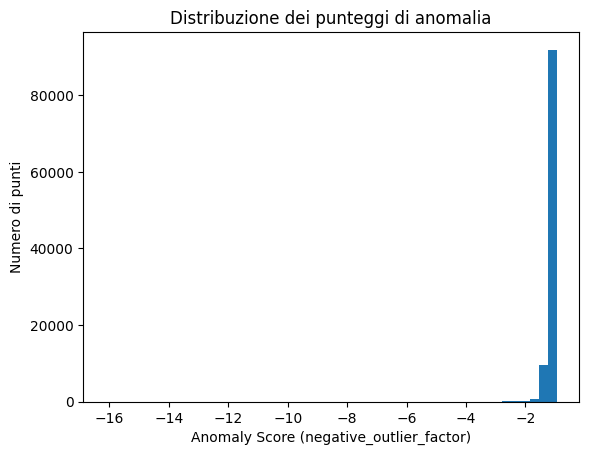

In [ ]:
plt.hist(df_results['anomaly_score'], bins=50)
plt.xlabel("Anomaly Score (negative_outlier_factor)")
plt.ylabel("Numero di punti")
plt.title("Distribuzione dei punteggi di anomalia")
plt.show()

In [14]:
y_true_flat = y_train_title.iloc[:, 0]

In [ ]:
y_pred

array([7, 8, 8, ..., 7, 6, 6])

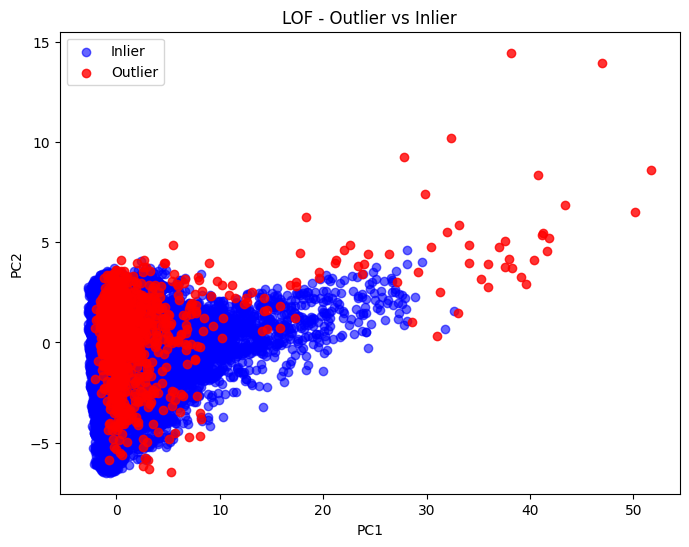

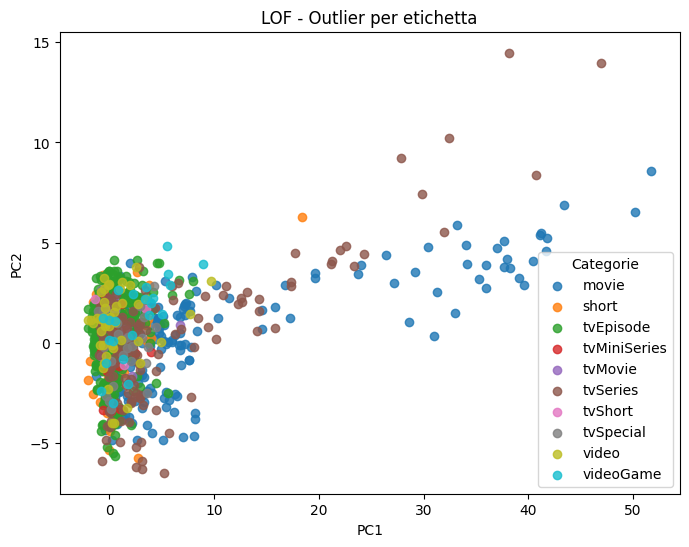

In [ ]:
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}

plot_outliers_pca(
    X_scaled=X_train_title_scaled,
    y_true=y_true_flat,      # o y_train_title.iloc[:, 0]
    is_outlier=y_pred_lof,
    label_map=label_map,     # <<< importante
    n_components=2,
    title_prefix="LOF"
)


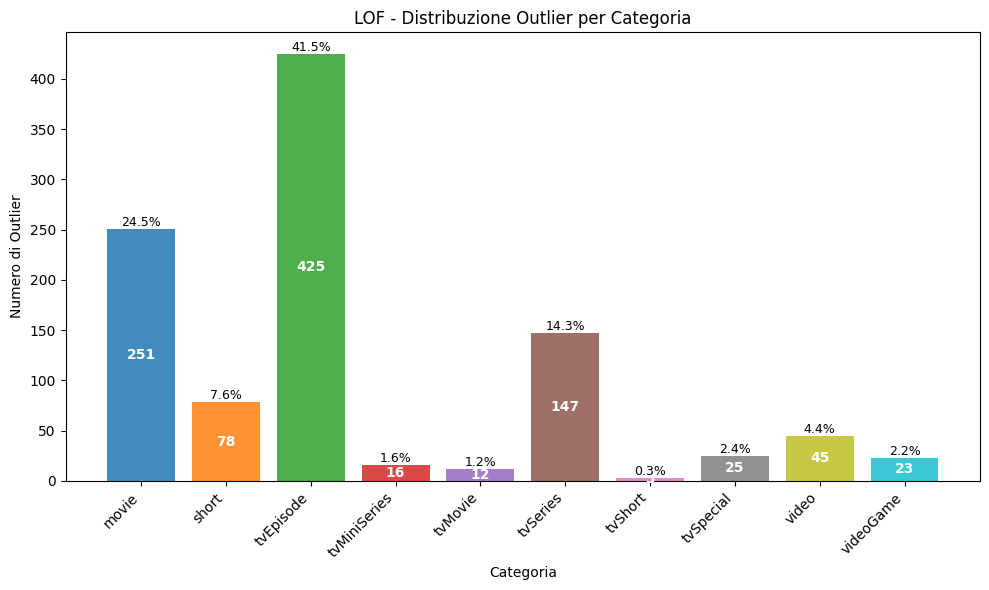

In [ ]:
barplot_outliers_by_label(
    df_results=df_results,
    y_true=y_true_flat,  # o y_true_flat
    label_map=label_map,
    title_prefix="LOF"
)

###TSNE LOF

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Applichiamo TSNE per ridurre a 2D
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_train_title_scaled)

# Creiamo un DataFrame con coordinate + risultati LOF
df_plot = pd.DataFrame(X_2d, columns=["x", "y"])
df_plot["is_outlier"] = df_results["is_outlier"].values
df_plot["anomaly_score"] = df_results["anomaly_score"].values
df_plot["label"] = y_true_flat.values  # <-- le tue etichette

# Mappa etichette
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}
inv_label_map = {v: k for k, v in label_map.items()}

# Plot
plt.figure(figsize=(12, 8))

# Inlier (is_outlier = 1)
plt.scatter(
    df_plot.loc[df_plot["is_outlier"] == 1, "x"],
    df_plot.loc[df_plot["is_outlier"] == 1, "y"],
    c="blue", label="Inlier", alpha=0.5, s=20
)

# Outlier (is_outlier = -1), colorati per tipo
outliers = df_plot[df_plot["is_outlier"] == -1]
for label_name, label_id in label_map.items():
    subset = outliers[outliers["label"] == label_id]
    if not subset.empty:
        plt.scatter(
            subset["x"], subset["y"],
            label=f"Outlier: {label_name}", s=50, alpha=0.8
        )

plt.title("t-SNE Projection with LOF Outliers", fontsize=14)
plt.legend()
plt.show()


NameError: name 'y_true_flat' is not defined

##ABOD

In [ ]:
from pyod.models.abod import ABOD

# Modello ABOD
abod = ABOD(contamination=0.01, n_neighbors=100)

# Fit + predizione
abod.fit(X_train_title_scaled)
y_pred_abod = abod.labels_            # 0 = inlier, 1 = outlier
anomaly_scores_abod = abod.decision_scores_

# Adattiamo a formato LOF (-1 / 1)
y_pred_abod = np.where(y_pred_abod == 1, -1, 1)

# DataFrame risultati
df_results_abod = pd.DataFrame({
    "is_outlier": y_pred_abod,
    "anomaly_score": anomaly_scores_abod
}, index=(X_train_title_scaled.index if isinstance(X_train_title_scaled, pd.DataFrame) else None))


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# TSNE
tsne = TSNE(n_components=2, random_state=42)
X_2d_abod = tsne.fit_transform(X_train_title_scaled)

# Creiamo DataFrame per il plot
df_plot_abod = pd.DataFrame(X_2d_abod, columns=["x", "y"])
df_plot_abod["is_outlier"] = df_results_abod["is_outlier"].values
df_plot_abod["anomaly_score"] = df_results_abod["anomaly_score"].values
df_plot_abod["label"] = y_true_flat.values  # etichette reali

# Mappa etichette
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}
inv_label_map = {v: k for k, v in label_map.items()}

# Plot
plt.figure(figsize=(12, 8))

# Inlier (is_outlier = 1)
plt.scatter(
    df_plot_abod.loc[df_plot_abod["is_outlier"] == 1, "x"],
    df_plot_abod.loc[df_plot_abod["is_outlier"] == 1, "y"],
    c="blue", label="Inlier", alpha=0.5, s=20
)

# Outlier (is_outlier = -1), colorati per tipo
outliers_abod = df_plot_abod[df_plot_abod["is_outlier"] == -1]
for label_name, label_id in label_map.items():
    subset = outliers_abod[outliers_abod["label"] == label_id]
    if not subset.empty:
        plt.scatter(
            subset["x"], subset["y"],
            label=f"Outlier: {label_name}", s=50, alpha=0.8
        )

plt.title("t-SNE Projection with ABOD Outliers", fontsize=14)
plt.legend()
plt.show()


In [ ]:
y_true_flat = y_train_title.iloc[:, 0]

In [ ]:
# Mappa etichette
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}
inv_label_map = {v: k for k, v in label_map.items()}

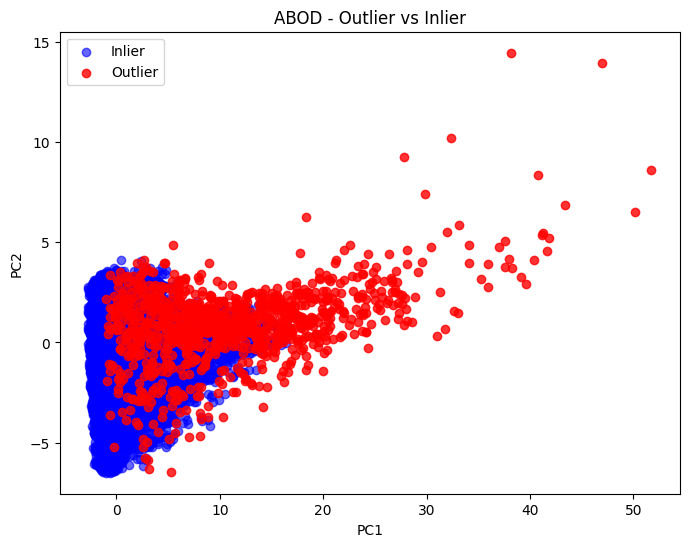

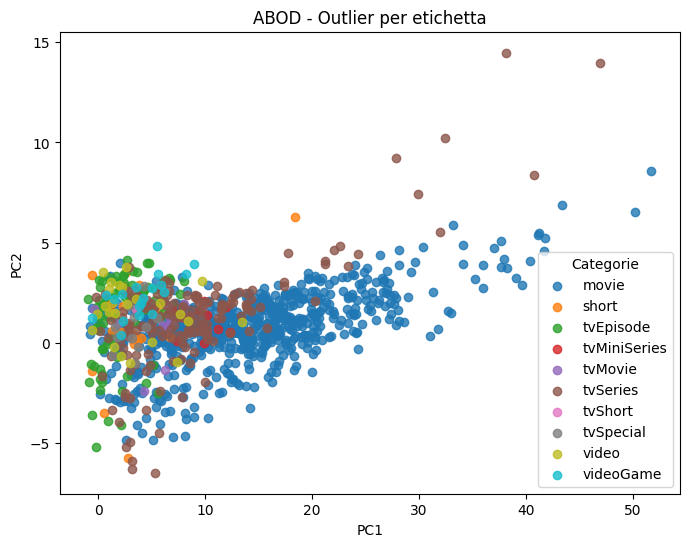

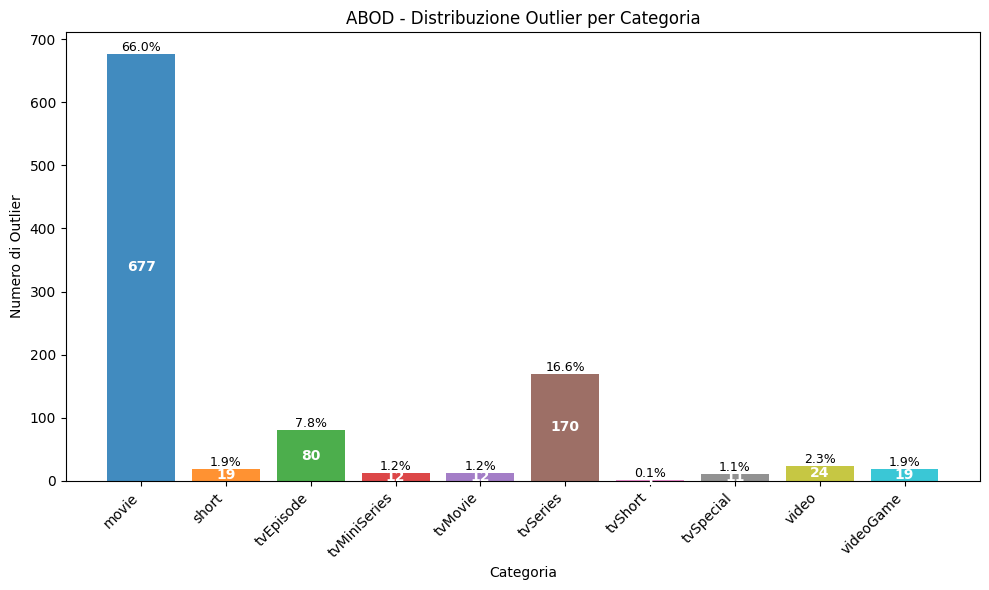

In [ ]:
plot_outliers_pca(X_train_title_scaled, y_true_flat, df_results_abod["is_outlier"], label_map, n_components=2, title_prefix="ABOD")
barplot_outliers_by_label(df_results_abod, y_true_flat, label_map, title_prefix="ABOD")

##ISOLATION FOREST

In [ ]:
from sklearn.ensemble import IsolationForest

# Modello Isolation Forest
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

# Fit + predizione
y_pred_iso = iso.fit_predict(X_train_title_scaled)  # già in formato -1 / 1
anomaly_scores_iso = iso.decision_function(X_train_title_scaled)

# DataFrame risultati
df_results_iso = pd.DataFrame({
    "is_outlier": y_pred_iso,
    "anomaly_score": anomaly_scores_iso
}, index=(X_train_title_scaled.index if isinstance(X_train_title_scaled, pd.DataFrame) else None))


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d_iso = tsne.fit_transform(X_train_title_scaled)

# Creiamo DataFrame per il plot
df_plot_iso = pd.DataFrame(X_2d_iso, columns=["x", "y"])
df_plot_iso["is_outlier"] = df_results_iso["is_outlier"].values
df_plot_iso["anomaly_score"] = df_results_iso["anomaly_score"].values
df_plot_iso["label"] = y_true_flat.values  # etichette reali

# Mappa etichette
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}
inv_label_map = {v: k for k, v in label_map.items()}

# Plot
plt.figure(figsize=(12, 8))

# Inlier (is_outlier = 1)
plt.scatter(
    df_plot_iso.loc[df_plot_iso["is_outlier"] == 1, "x"],
    df_plot_iso.loc[df_plot_iso["is_outlier"] == 1, "y"],
    c="blue", label="Inlier", alpha=0.5, s=20
)

# Outlier (is_outlier = -1), colorati per tipo
outliers_iso = df_plot_iso[df_plot_iso["is_outlier"] == -1]
for label_name, label_id in label_map.items():
    subset = outliers_iso[outliers_iso["label"] == label_id]
    if not subset.empty:
        plt.scatter(
            subset["x"], subset["y"],
            label=f"Outlier: {label_name}", s=50, alpha=0.8
        )

plt.title("t-SNE Projection with Isolation Forest Outliers", fontsize=14)
plt.legend()
plt.show()


In [ ]:
y_true_flat = y_train_title.iloc[:, 0]

In [ ]:
# Mappa etichette
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}
inv_label_map = {v: k for k, v in label_map.items()}

In [ ]:
plot_outliers_pca(X_train_title_scaled, y_true_flat, df_results_iso["is_outlier"], label_map, n_components=2, title_prefix="Isolation Forest")
barplot_outliers_by_label(df_results_iso, y_true_flat, label_map, title_prefix="Isolation Forest")

##TSNE per tutti gli algoritmi

In [ ]:
from sklearn.manifold import TSNE

# Riduzione dimensionale a 2D (una sola volta)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_train_title_scaled)

# DataFrame base con coordinate TSNE e etichette reali
df_plot_base = pd.DataFrame(X_2d, columns=["x", "y"])
df_plot_base["label"] = y_true_flat.values


In [ ]:
X_train_title_scaled.shape

(102432, 15)

In [ ]:
# LOF
df_plot_lof = df_plot_base.copy()
df_plot_lof["is_outlier"] = df_results["is_outlier"].values
df_plot_lof["anomaly_score"] = df_results["anomaly_score"].values

# ABOD
df_plot_abod = df_plot_base.copy()
df_plot_abod["is_outlier"] = df_results_abod["is_outlier"].values
df_plot_abod["anomaly_score"] = df_results_abod["anomaly_score"].values

# Isolation Forest
df_plot_iso = df_plot_base.copy()
df_plot_iso["is_outlier"] = df_results_iso["is_outlier"].values
df_plot_iso["anomaly_score"] = df_results_iso["anomaly_score"].values


In [ ]:
def plot_tsne_outliers(df_plot, title, label_map):
    plt.figure(figsize=(12, 8))

    # Inlier
    plt.scatter(
        df_plot.loc[df_plot["is_outlier"] == 1, "x"],
        df_plot.loc[df_plot["is_outlier"] == 1, "y"],
        c="blue", label="Inlier", alpha=0.5, s=20
    )

    # Outlier per classe
    outliers = df_plot[df_plot["is_outlier"] == -1]
    for label_name, label_id in label_map.items():
        subset = outliers[outliers["label"] == label_id]
        if not subset.empty:
            plt.scatter(
                subset["x"], subset["y"],
                label=f"Outlier: {label_name}", s=50, alpha=0.8
            )

    plt.title(title, fontsize=14)
    plt.legend()
    plt.show()


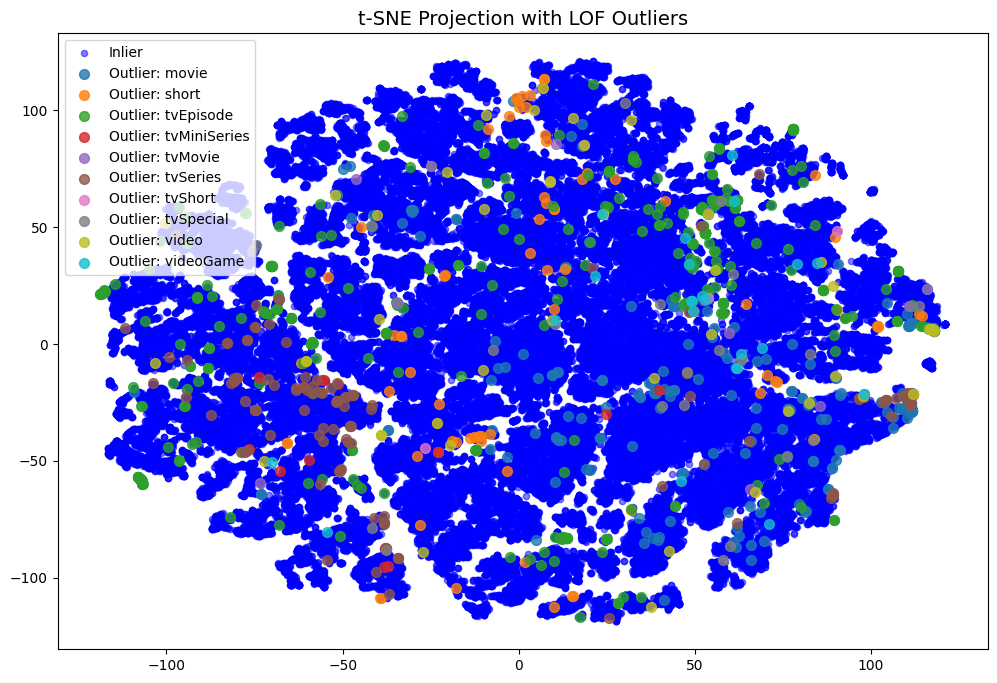

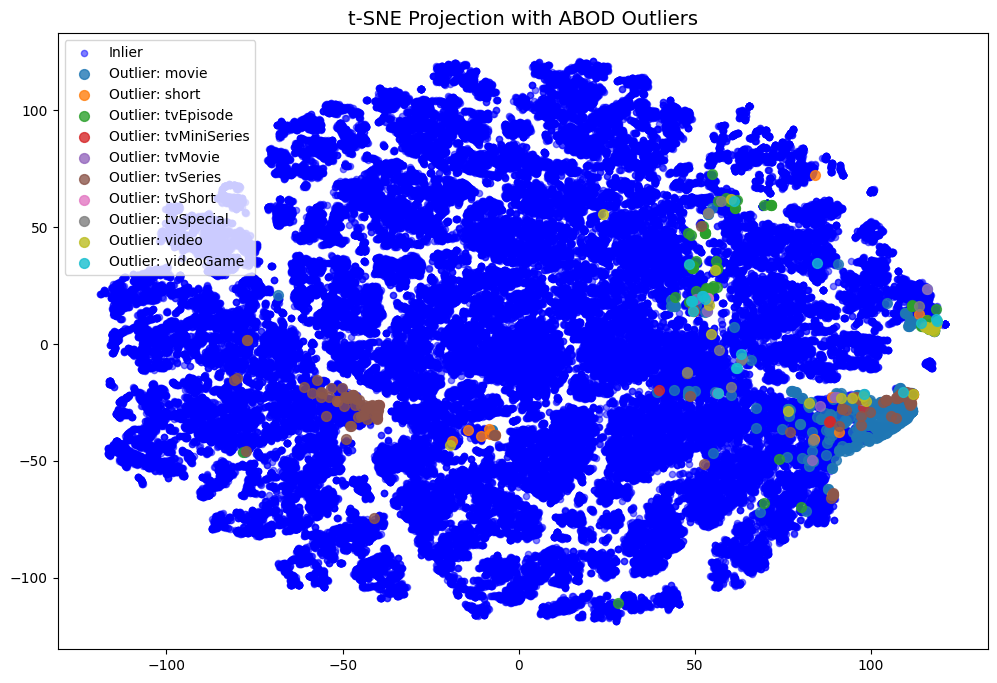

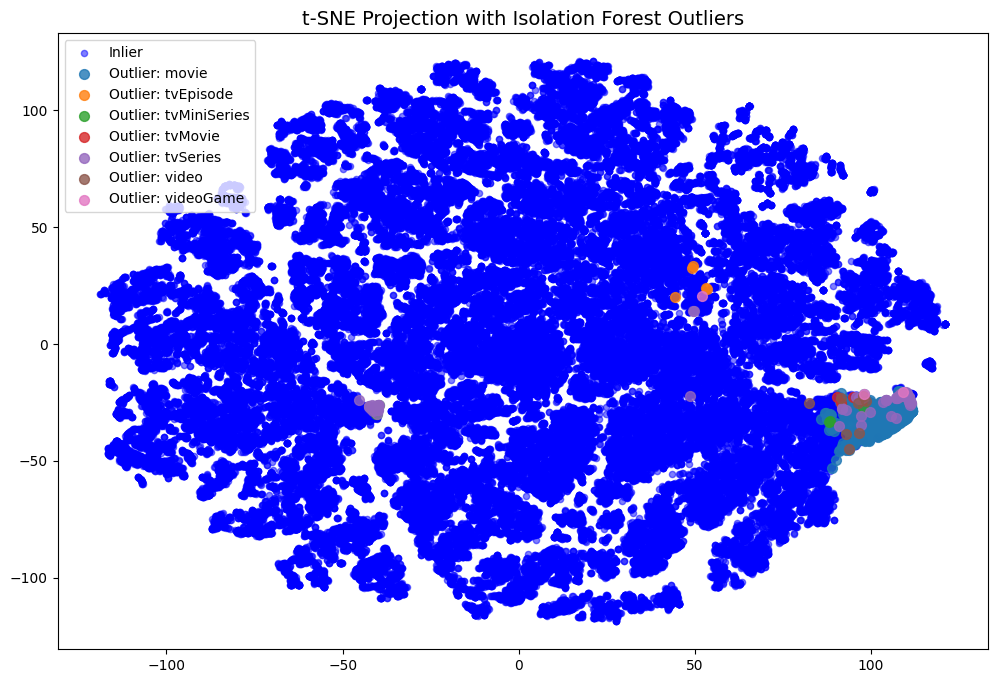

In [ ]:
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}

plot_tsne_outliers(df_plot_lof, "t-SNE Projection with LOF Outliers", label_map)
plot_tsne_outliers(df_plot_abod, "t-SNE Projection with ABOD Outliers", label_map)
plot_tsne_outliers(df_plot_iso, "t-SNE Projection with Isolation Forest Outliers", label_map)


In [ ]:
from sklearn.manifold import TSNE
# TSNE a 3 dimensioni
tsne = TSNE(n_components=3, random_state=42)
X_3d = tsne.fit_transform(X_train_title_scaled)

# DataFrame con 3 colonne
df_plot_base2 = pd.DataFrame(X_3d, columns=["x", "y", "z"])
df_plot_base2["label"] = y_true_flat.values


In [ ]:
# LOF
df_plot_lof2 = df_plot_base2.copy()
df_plot_lof2["is_outlier"] = df_results["is_outlier"].values
df_plot_lof2["anomaly_score"] = df_results["anomaly_score"].values

# ABOD
df_plot_abod2 = df_plot_base2.copy()
df_plot_abod2["is_outlier"] = df_results_abod["is_outlier"].values
df_plot_abod2["anomaly_score"] = df_results_abod["anomaly_score"].values

# Isolation Forest
df_plot_iso2 = df_plot_base2.copy()
df_plot_iso2["is_outlier"] = df_results_iso["is_outlier"].values
df_plot_iso2["anomaly_score"] = df_results_iso["anomaly_score"].values


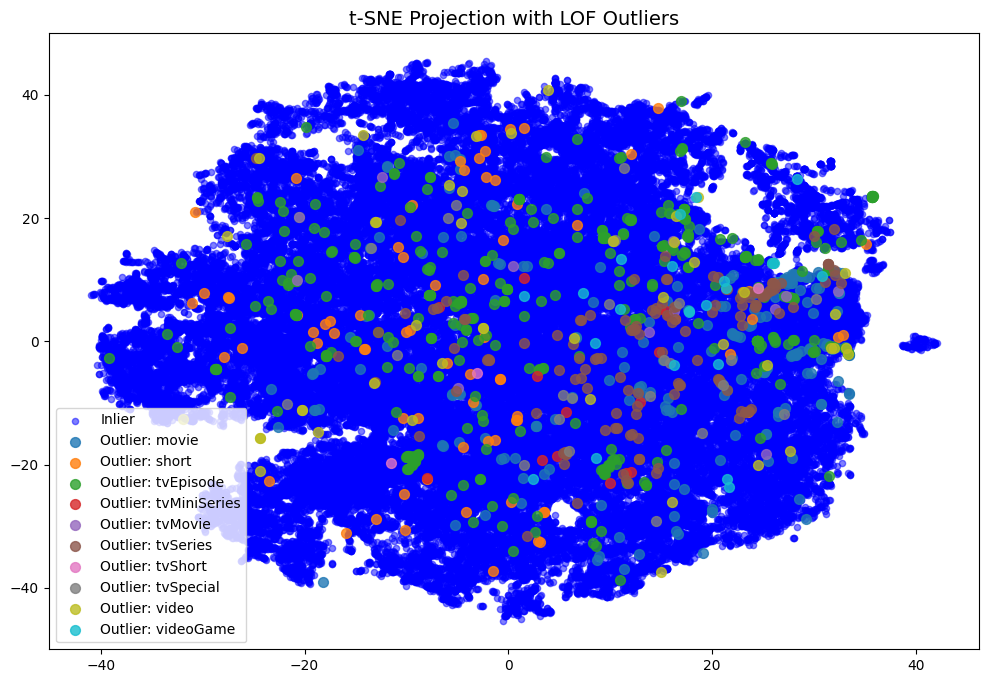

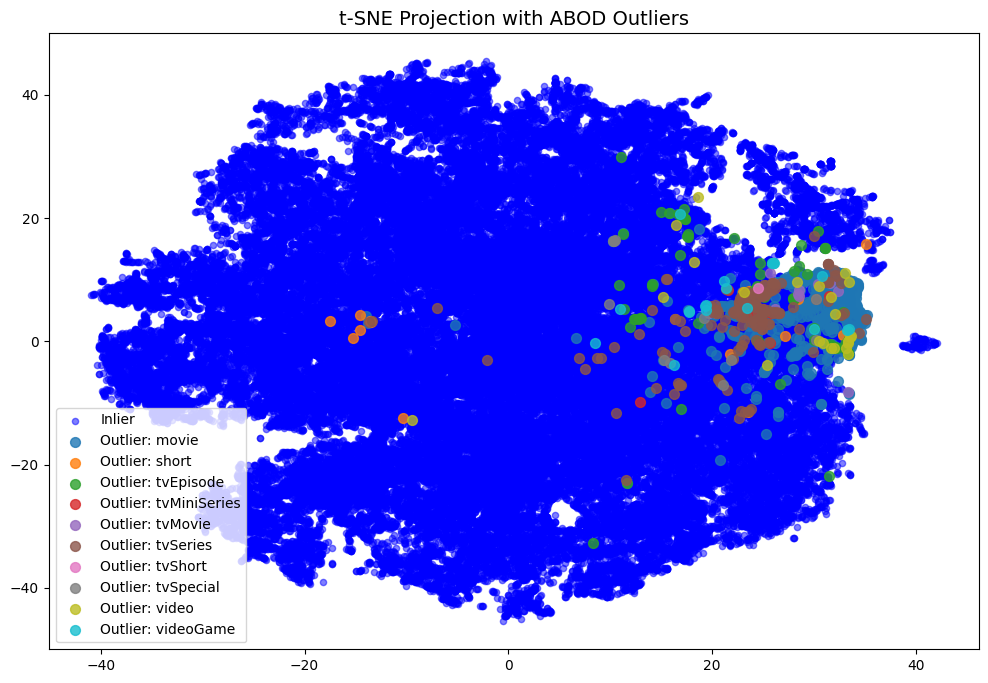

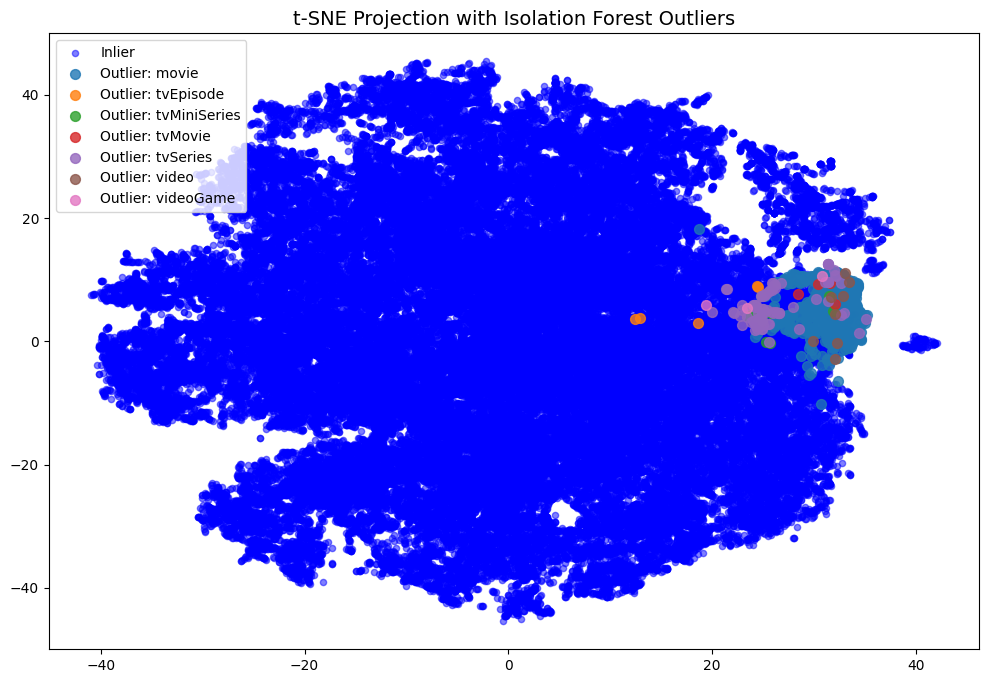

In [ ]:
label_map = {
    'movie': 0, 'short': 1, 'tvEpisode': 2, 'tvMiniSeries': 3,
    'tvMovie': 4, 'tvSeries': 5, 'tvShort': 6, 'tvSpecial': 7,
    'video': 8, 'videoGame': 9
}

plot_tsne_outliers(df_plot_lof2, "t-SNE Projection with LOF Outliers", label_map)
plot_tsne_outliers(df_plot_abod2, "t-SNE Projection with ABOD Outliers", label_map)
plot_tsne_outliers(df_plot_iso2, "t-SNE Projection with Isolation Forest Outliers", label_map)


#Classificatori per LOF, ABOD e IF

In [ ]:
def train_rf_on_filtered_data(
    X_train_full,
    y_train,
    X_test_full,
    y_test,
    mask_inliers,
    random_state=42
):
    X_train_filtered = X_train_full.loc[mask_inliers].copy()
    y_train_filtered = y_train.loc[mask_inliers].copy()

    clf = RandomForestClassifier(random_state=random_state)
    clf.fit(X_train_filtered, y_train_filtered)

    y_pred_test = clf.predict(X_test_full)

    acc = accuracy_score(y_test, y_pred_test)
    report = classification_report(y_test, y_pred_test)

    return {
        "model": clf,
        "accuracy": acc,
        "classification_report": report,
        "num_train_before": len(X_train_full),
        "num_train_after": len(X_train_filtered),
    }


In [ ]:
mask_lof = (y_pred_lof == 1)
mask_abod = (y_pred_abod == 1)
mask_if = (y_pred_iso == 1)

results_lof = train_rf_on_filtered_data(X_train_title_final, y_train_title, X_test_title_final, y_test_title, mask_lof)
results_abod = train_rf_on_filtered_data(X_train_title_final, y_train_title, X_test_title_final, y_test_title, mask_abod)
results_if = train_rf_on_filtered_data(X_train_title_final, y_train_title, X_test_title_final, y_test_title, mask_if)

print("LOF Classification Report:\n", results_lof["classification_report"])
print("ABOD Classification Report:\n", results_abod["classification_report"])
print("Isolation Forest Classification Report:\n", results_if["classification_report"])


LOF Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92     10672
           1       0.92      0.97      0.95      4913
           2       0.96      0.99      0.98     21063
           3       0.70      0.31      0.43       467
           4       0.69      0.31      0.43      1755
           5       0.85      0.96      0.90      2647
           6       0.57      0.05      0.09        81
           7       0.64      0.24      0.35       311
           8       0.83      0.45      0.58      1494
           9       0.91      0.65      0.76       497

    accuracy                           0.92     43900
   macro avg       0.80      0.59      0.64     43900
weighted avg       0.91      0.92      0.90     43900

ABOD Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92     10672
           1       0.93      0.97      0.95      4913
           2       0.

#Divisione X, y  rating

In [ ]:
train_rating = pd.read_csv('/content/train_rating.csv')

In [ ]:
test_rating = pd.read_csv('/content/test_rating.csv')

In [ ]:
# Divisione train/test rating type
X_train_rating = train_rating.drop(columns= [ 'rating' ])
y_train_rating = train_rating[['rating']]
X_test_rating = test_rating.drop(columns= [ 'rating' ])
y_test_rating = test_rating[['rating']]


In [ ]:
X_train_rating = X_train_rating.drop(columns= [ 'averageRating' ])


In [ ]:
X_test_rating = X_test_rating.drop(columns= [ 'averageRating' ])


In [ ]:
X_train_rating.head()

,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,externalLinks,writerCredits,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,1968,78.0,953,58,35,14,38,24,43,2,...,1,0,0,0,0,0,0,0,0,0
1,2010,32.0,5,9,0,0,0,2,0,0,...,0,0,0,0,0,1,0,0,0,0
2,2022,77.0,2671,145,12,33,32,22,18,3,...,1,0,0,0,0,0,0,0,0,0
3,1990,25.0,406,112,0,11,3,23,4,0,...,0,0,0,0,0,1,0,0,0,0
4,2021,20.0,9,143,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,0


#Trasformazione Log e Standard Scaling

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# === 1. Colonne da trasformare ===
log_columns = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']
all_numeric_columns = [ 'runtimeMinutes', 'numVotes', 'totalCredits',
                       'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
                       'companiesNumber', 'externalLinks',
                       'writerCredits', 'directorsCredits', 'quotesTotal',
                       'totalMedia', 'totalNominations']

# === 2. Funzione per preprocessing ===
def preprocess_numeric(df, log_cols, all_cols, scaler=None, fit_scaler=True):
    df_copy = df[all_cols].copy()

    # Log transformation (safe for zeros)
    df_copy[log_cols] = df_copy[log_cols].clip(lower=0).apply(np.log1p)

    # Scaling
    if fit_scaler:
        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_copy)
    else:
        df_scaled = scaler.transform(df_copy)

    # Return DataFrame and scaler
    return pd.DataFrame(df_scaled, columns=all_cols, index=df.index), scaler

# === 3. Preprocessing train ===
X_train_rating_scaled, scaler = preprocess_numeric(X_train_rating, log_columns, all_numeric_columns)

# === 4. Preprocessing test ===
X_test_rating_scaled, _ = preprocess_numeric(X_test_rating, log_columns, all_numeric_columns, scaler, fit_scaler=False)


In [ ]:
X_train_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102432 entries, 0 to 102431
Data columns (total 58 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   startYear               102432 non-null  int64  
 1   runtimeMinutes          102432 non-null  float64
 2   numVotes                102432 non-null  int64  
 3   totalCredits            102432 non-null  int64  
 4   criticReviewsTotal      102432 non-null  int64  
 5   numRegions              102432 non-null  int64  
 6   userReviewsTotal        102432 non-null  int64  
 7   companiesNumber         102432 non-null  int64  
 8   externalLinks           102432 non-null  int64  
 9   writerCredits           102432 non-null  int64  
 10  directorsCredits        102432 non-null  int64  
 11  quotesTotal             102432 non-null  int64  
 12  totalMedia              102432 non-null  int64  
 13  totalNominations        102432 non-null  int64  
 14  genres_Action       

#DF TRAIN E TEST CON DATI SCALATI+ ALTRE COLONNE

##Train

In [ ]:
# Creiamo una copia per non modificare gli originali
X_train_rating_copy = X_train_rating.copy()
X_test_rating_copy = X_test_rating.copy()

# Elencorating.colonne che sono state scalate
scaled_columns = all_numeric_columns

# Colonne da mantenere (quelle non numeriche)
other_columns = [col for col in X_train_rating.columns if col not in scaled_columns]
# Seleziona le colonne non numeriche dalla copia di X_train_title
X_train_rating_other = X_train_rating_copy[other_columns]

# Unisci il DataFrame scalato con le altre colonne
# Utilizziamo l'indice per garantire che l'unione sia corretta
X_train_rating_final = pd.concat([X_train_rating_scaled, X_train_rating_other], axis=1)



In [ ]:
X_train_rating_final.head()

,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,externalLinks,writerCredits,directorsCredits,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,0.800513,1.783457,0.532681,2.310461,2.074393,3.077229,0.899616,1.866456,-0.011492,0.062745,...,1,0,0,0,0,0,0,0,0,0
1,-0.287458,-1.240042,-1.092758,-0.158866,-0.537147,-0.576993,-0.195451,-0.262389,-0.813898,-1.178001,...,0,0,0,0,0,1,0,0,0,0
2,0.784636,2.397782,1.362427,0.687761,5.618627,2.910600,0.800065,0.628755,0.389711,1.303490,...,1,0,0,0,0,0,0,0,0,0
3,-0.584596,1.275345,1.127791,-0.158866,1.514777,0.805767,0.849841,-0.064357,-0.813898,-1.178001,...,0,0,0,0,0,1,0,0,0,0
4,-0.850780,-0.935344,1.349796,-0.158866,-0.537147,-0.576993,-0.195451,-0.262389,-0.813898,0.062745,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Seleziona le colonne non numeriche dalla copia di X_test_title
X_test_rating_other = X_test_rating_copy[other_columns]

# Unisci il DataFrame scalato con le altre colonne
# Utilizziamo l'indice per garantire che l'unione sia corretta
X_test_rating_final = pd.concat([X_test_rating_scaled, X_test_rating_other], axis=1)


In [ ]:
X_train_rating_final

,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,externalLinks,writerCredits,directorsCredits,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,0.800513,1.783457,0.532681,2.310461,2.074393,3.077229,0.899616,1.866456,-0.011492,0.062745,...,1,0,0,0,0,0,0,0,0,0
1,-0.287458,-1.240042,-1.092758,-0.158866,-0.537147,-0.576993,-0.195451,-0.262389,-0.813898,-1.178001,...,0,0,0,0,0,1,0,0,0,0
2,0.784636,2.397782,1.362427,0.687761,5.618627,2.910600,0.800065,0.628755,0.389711,1.303490,...,1,0,0,0,0,0,0,0,0,0
3,-0.584596,1.275345,1.127791,-0.158866,1.514777,0.805767,0.849841,-0.064357,-0.813898,-1.178001,...,0,0,0,0,0,1,0,0,0,0
4,-0.850780,-0.935344,1.349796,-0.158866,-0.537147,-0.576993,-0.195451,-0.262389,-0.813898,0.062745,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102427,1.166923,-0.552492,-0.117733,-0.158866,-0.350608,0.114387,-0.195451,-0.262389,-0.412695,0.062745,...,0,0,0,0,0,0,0,0,1,0
102428,0.831673,-0.552492,-1.189243,-0.158866,-0.350608,-0.576993,-0.195451,-0.212881,-0.813898,0.062745,...,1,0,0,0,0,0,0,0,0,0
102429,-2.053588,0.250382,-0.606827,-0.158866,-0.350608,1.210199,-0.195451,-0.262389,-0.011492,1.303490,...,0,1,0,0,0,0,0,0,0,0
102430,-0.584596,-0.935344,-0.086688,-0.158866,-0.350608,-0.576993,-0.245227,-0.163373,-0.813898,-1.178001,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
X_train_rating_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102432 entries, 0 to 102431
Data columns (total 58 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   runtimeMinutes          102432 non-null  float64
 1   numVotes                102432 non-null  float64
 2   totalCredits            102432 non-null  float64
 3   criticReviewsTotal      102432 non-null  float64
 4   numRegions              102432 non-null  float64
 5   userReviewsTotal        102432 non-null  float64
 6   companiesNumber         102432 non-null  float64
 7   externalLinks           102432 non-null  float64
 8   writerCredits           102432 non-null  float64
 9   directorsCredits        102432 non-null  float64
 10  quotesTotal             102432 non-null  float64
 11  totalMedia              102432 non-null  float64
 12  totalNominations        102432 non-null  float64
 13  startYear               102432 non-null  int64  
 14  genres_Action       

In [ ]:
X_test_rating_final

,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,externalLinks,writerCredits,directorsCredits,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,1.043423,-0.778850,0.284623,-0.158866,-0.164070,-0.576993,-0.295002,-0.212881,1.593321,0.062745,...,0,0,0,0,1,0,0,0,0,0
1,-0.365379,-0.878494,-0.457998,-0.158866,-0.537147,-0.576993,-0.245227,-0.262389,-0.011492,0.062745,...,0,0,1,0,0,0,0,0,0,0
2,-1.548245,0.152962,1.077828,-0.158866,-0.537147,-0.576993,-0.295002,-0.262389,4.000540,0.062745,...,0,0,1,0,0,0,0,0,0,0
3,0.752262,0.599166,-1.005476,-0.158866,-0.350608,-0.576993,-0.245227,-0.262389,-0.813898,0.062745,...,0,0,0,0,0,0,0,0,1,0
4,-1.189699,-1.148094,0.399243,-0.158866,-0.350608,-0.576993,-0.295002,-0.262389,-0.412695,0.062745,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43895,-1.356123,-0.826593,-0.370717,-0.158866,-0.350608,-0.576993,-0.245227,-0.113865,-0.412695,0.062745,...,0,1,0,0,0,0,0,0,0,0
43896,0.042436,-0.878494,0.635354,-0.158866,-0.537147,-0.576993,-0.295002,-0.212881,-0.813898,0.062745,...,0,0,1,0,0,0,0,0,0,0
43897,-1.448486,-0.584742,-0.925794,-0.158866,-0.350608,-0.576993,-0.195451,-0.262389,-0.412695,0.062745,...,0,1,0,0,0,0,0,0,0,0
43898,-1.114141,-0.935344,-0.852494,-0.158866,-0.350608,-0.576993,-0.245227,-0.212881,-0.412695,0.062745,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
from google.colab import files

In [ ]:

# Salvataggio su Colab
X_test_rating_final.to_csv("X_test_rating_final.csv", index=False)
y_test_rating.to_csv("y_test_rating.csv", index=False)

# Download immediato
files.download("X_test_rating_final.csv")
files.download("y_test_rating.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_test_rating.shape

(43900, 1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Inizializza e allena il classificatore
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_rating_final, y_train_rating)

# Predizione sul test set
y_pred = clf.predict(X_test_rating_final)

# Valutazione
print("📊 Classification Report:")
print(classification_report(y_test_rating, y_pred))


📊 Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.16      0.24        64
           2       0.46      0.09      0.15       192
           3       0.39      0.08      0.13       516
           4       0.36      0.14      0.20      1512
           5       0.38      0.22      0.28      3769
           6       0.41      0.43      0.42      8246
           7       0.45      0.56      0.50     13559
           8       0.51      0.59      0.55     11998
           9       0.50      0.22      0.31      3583
          10       0.61      0.21      0.31       461

    accuracy                           0.46     43900
   macro avg       0.46      0.27      0.31     43900
weighted avg       0.46      0.46      0.44     43900



#Outlier Detection

##Pipeline modulare

In [ ]:
neighbors_list = [30, 50, 100, 200]

for n in neighbors_list:
    print(f"\n🔍 Esecuzione pipeline con n_neighbors = {n}")
    run_outlier_pipeline(
        X_train_numeric=X_train_rating_scaled,
        X_train_full=X_train_rating_final,
        y_train=y_train_rating,
        X_test_full=X_test_rating_final,
        y_test=y_test_rating,
        contamination=0.01,
        n_neighbors=n
    )



🔍 Esecuzione pipeline con n_neighbors = 30
🧹 Outlier comuni a tutti e 3: 42
🧹 Outlier comuni ad almeno 2 su 3: 730

📊 Risultati per dataset 'No Outliers (All 3)':
              precision    recall  f1-score   support

           1       0.55      0.17      0.26        64
           2       0.50      0.10      0.17       192
           3       0.39      0.09      0.14       516
           4       0.34      0.13      0.19      1512
           5       0.38      0.23      0.29      3769
           6       0.42      0.43      0.43      8246
           7       0.45      0.56      0.50     13559
           8       0.51      0.59      0.55     11998
           9       0.50      0.23      0.31      3583
          10       0.64      0.21      0.32       461

    accuracy                           0.46     43900
   macro avg       0.47      0.27      0.32     43900
weighted avg       0.46      0.46      0.45     43900


📊 Risultati per dataset 'No Outliers (2 of 3)':
              precision    r

KeyboardInterrupt: 

In [ ]:
neighbors_list = [100]

for n in neighbors_list:
    print(f"\n🔍 Esecuzione pipeline con n_neighbors = {n}")
    run_outlier_pipeline(
        X_train_numeric=X_train_rating_scaled,
        X_train_full=X_train_rating_final,
        y_train=y_train_rating,
        X_test_full=X_test_rating_final,
        y_test=y_test_rating,
        contamination=0.01,
        n_neighbors=n
    )



🔍 Esecuzione pipeline con n_neighbors = 100
🧹 Outlier comuni a tutti e 3: 72
🧹 Outlier comuni ad almeno 2 su 3: 813

📊 Risultati per dataset 'No Outliers (All 3)':
              precision    recall  f1-score   support

           1       0.50      0.16      0.24        64
           2       0.42      0.09      0.15       192
           3       0.38      0.08      0.13       516
           4       0.35      0.13      0.19      1512
           5       0.37      0.23      0.28      3769
           6       0.42      0.43      0.43      8246
           7       0.45      0.56      0.50     13559
           8       0.51      0.59      0.54     11998
           9       0.51      0.22      0.31      3583
          10       0.61      0.21      0.31       461

    accuracy                           0.46     43900
   macro avg       0.45      0.27      0.31     43900
weighted avg       0.46      0.46      0.45     43900


📊 Risultati per dataset 'No Outliers (2 of 3)':
              precision    

##LOF

In [ ]:
# Import
from sklearn.neighbors import LocalOutlierFactor
import pandas as pd
import matplotlib.pyplot as plt

# Creazione modello LOF (metric default = 'minkowski')
lof = LocalOutlierFactor(
    n_neighbors=100,
    contamination=0.01,  # adatta in base ai tuoi dati
)

# Predizione
y_pred_lof = lof.fit_predict(X_train_rating_scaled)
anomaly_scores = lof.negative_outlier_factor_

# DataFrame risultati
df_results = pd.DataFrame({
    "is_outlier": y_pred_lof,
    "anomaly_score": anomaly_scores
}, index=(X_train_rating_scaled.index if isinstance(X_train_rating_scaled, pd.DataFrame) else None))



In [ ]:
y_true_flat = y_train_rating.iloc[:, 0]

In [ ]:
label_map = {
     '1': 1, '2': 2, '3': 3,
    '4': 4, '5': 5, '6': 6, '7': 7,
    '8': 8, '9': 9, '10':10,
}

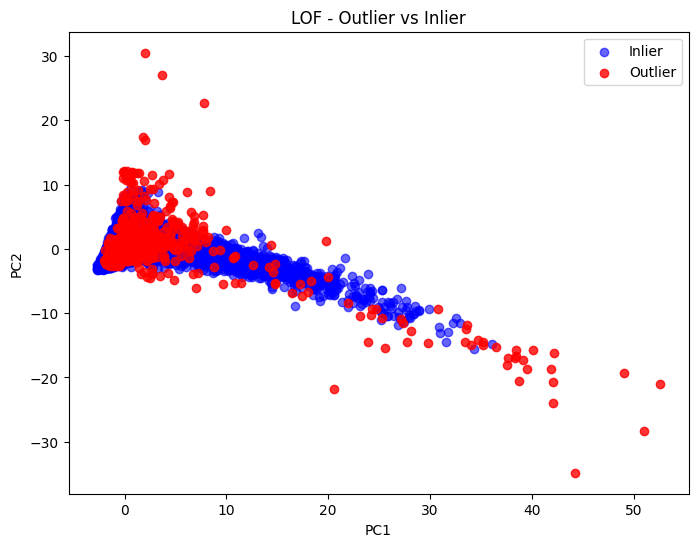

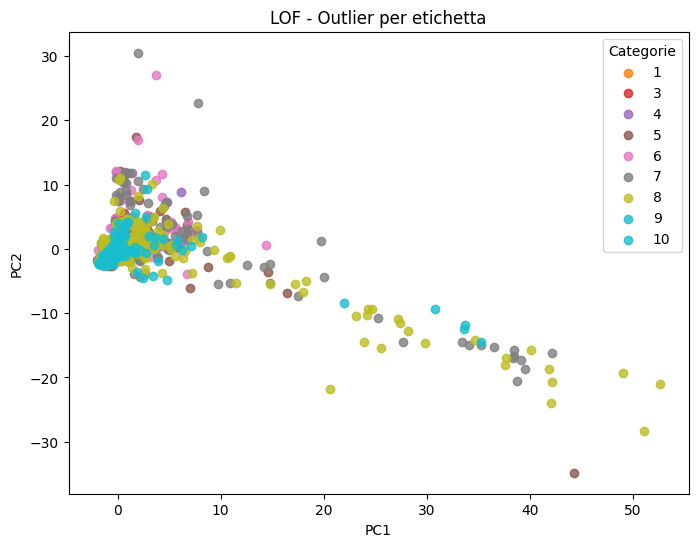

In [ ]:


plot_outliers_pca(
    X_scaled=X_train_rating_scaled,
    y_true=y_true_flat,      # o y_train_title.iloc[:, 0]
    is_outlier=y_pred_lof,
    label_map=label_map,     # <<< importante
    n_components=2,
    title_prefix="LOF"
)


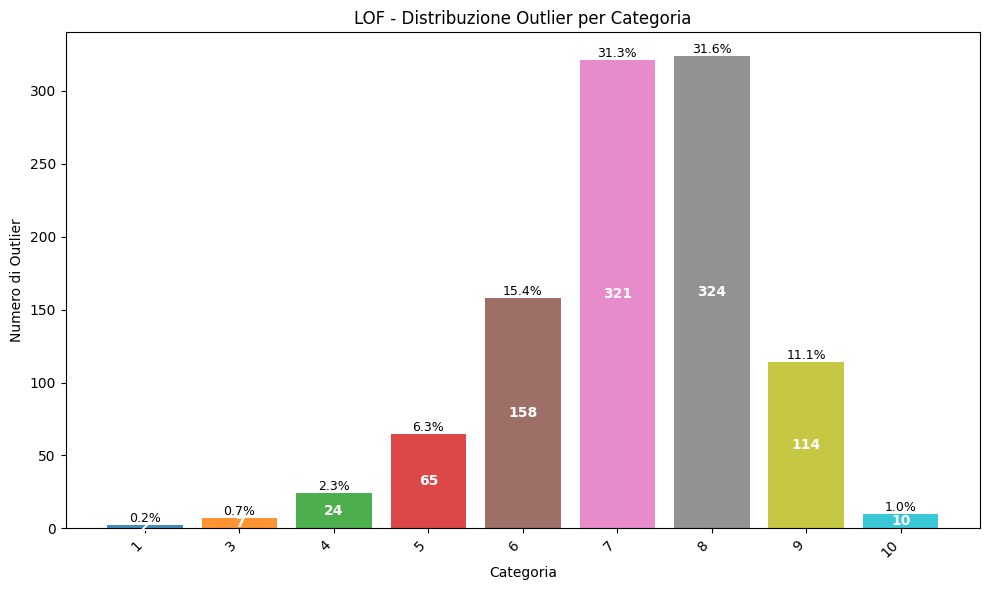

In [ ]:
barplot_outliers_by_label(
    df_results=df_results,
    y_true=y_true_flat,  # o y_true_flat
    label_map=label_map,
    title_prefix="LOF"
)

##ABOD

In [ ]:
from pyod.models.abod import ABOD

# Modello ABOD
abod = ABOD(contamination=0.01, n_neighbors=100)

# Fit + predizione
abod.fit(X_train_rating_scaled)
y_pred_abod = abod.labels_            # 0 = inlier, 1 = outlier
anomaly_scores_abod = abod.decision_scores_

# Adattiamo a formato LOF (-1 / 1)
y_pred_abod = np.where(y_pred_abod == 1, -1, 1)

# DataFrame risultati
df_results_abod = pd.DataFrame({
    "is_outlier": y_pred_abod,
    "anomaly_score": anomaly_scores_abod
}, index=(X_train_rating_scaled.index if isinstance(X_train_rating_scaled, pd.DataFrame) else None))


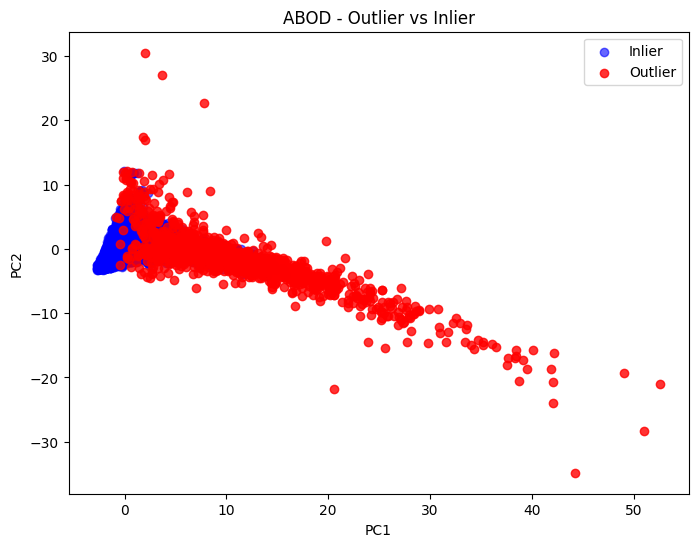

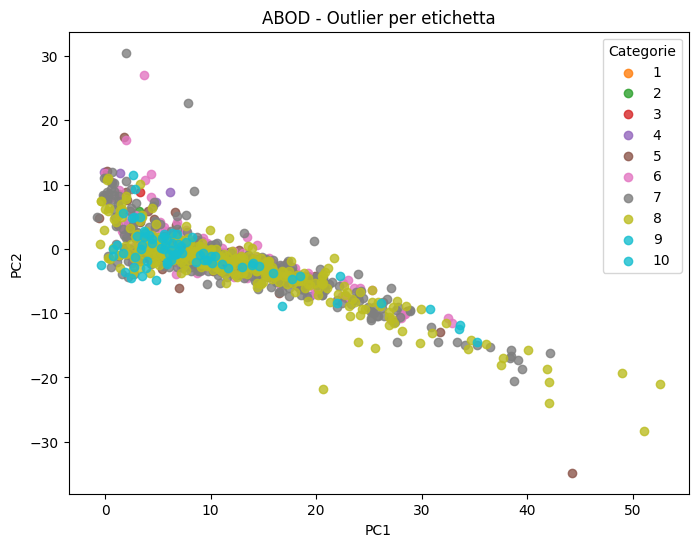

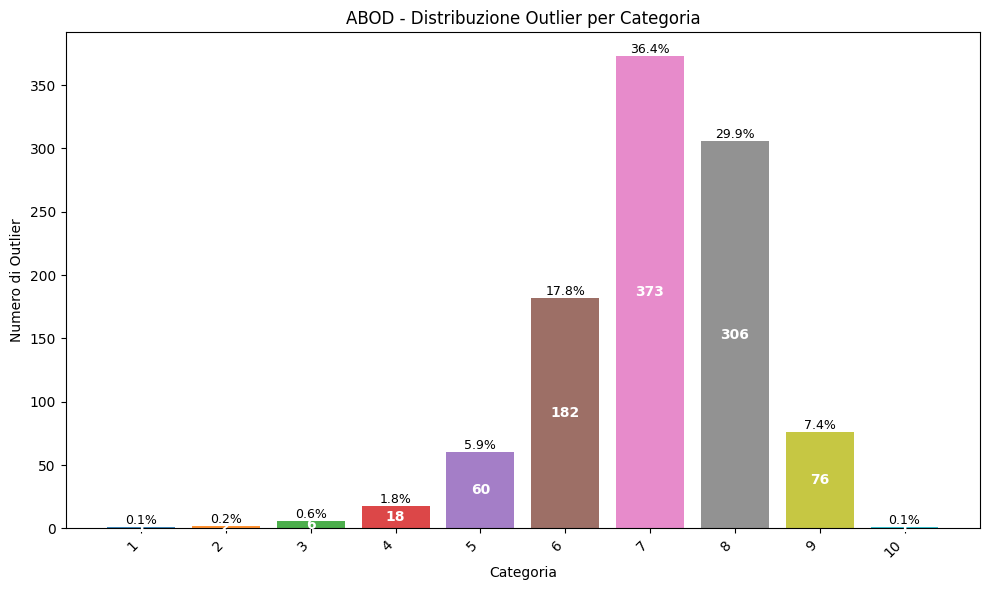

In [ ]:
plot_outliers_pca(X_train_rating_scaled, y_true_flat, df_results_abod["is_outlier"], label_map, n_components=2, title_prefix="ABOD")
barplot_outliers_by_label(df_results_abod, y_true_flat, label_map, title_prefix="ABOD")

##ISOLATION FOREST

In [ ]:
from sklearn.ensemble import IsolationForest

# Modello Isolation Forest
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

# Fit + predizione
y_pred_iso = iso.fit_predict(X_train_rating_scaled)  # già in formato -1 / 1
anomaly_scores_iso = iso.decision_function(X_train_rating_scaled)

# DataFrame risultati
df_results_iso = pd.DataFrame({
    "is_outlier": y_pred_iso,
    "anomaly_score": anomaly_scores_iso
}, index=(X_train_rating_scaled.index if isinstance(X_train_rating_scaled, pd.DataFrame) else None))


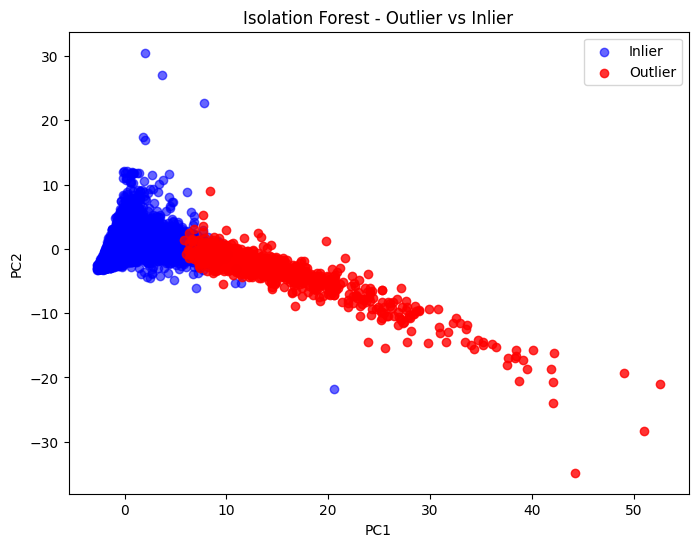

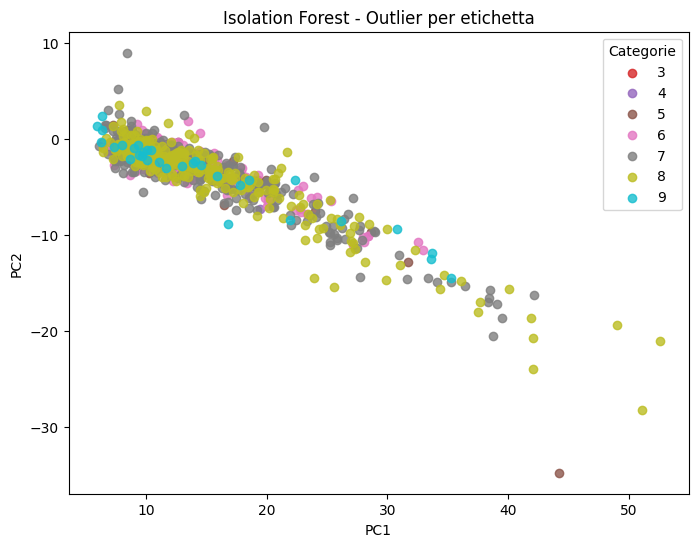

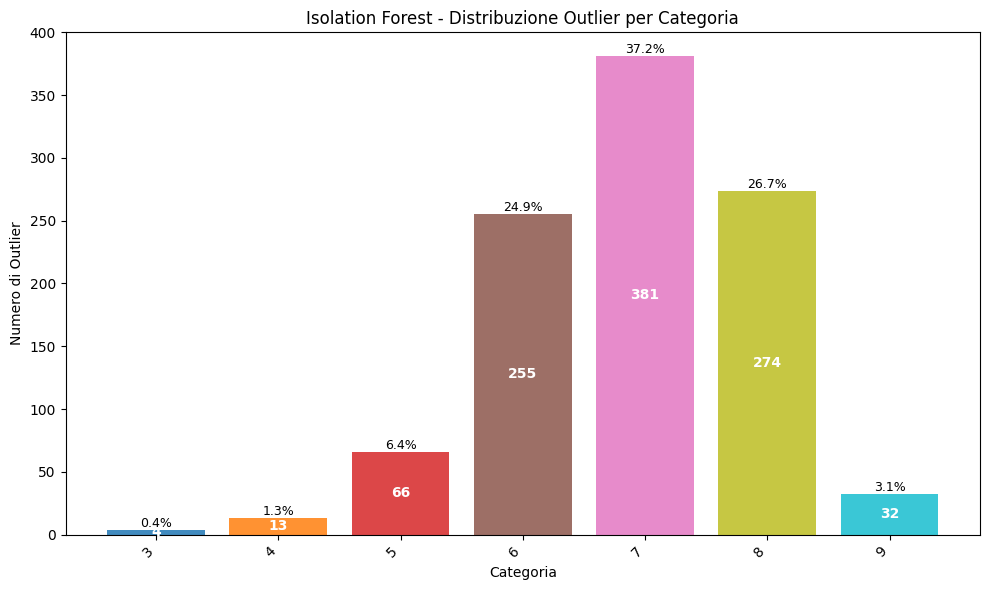

In [ ]:
plot_outliers_pca(X_train_rating_scaled, y_true_flat, df_results_iso["is_outlier"], label_map, n_components=2, title_prefix="Isolation Forest")
barplot_outliers_by_label(df_results_iso, y_true_flat, label_map, title_prefix="Isolation Forest")

#Classificatori per LOF, ABOD e IF

In [ ]:
def train_rf_on_filtered_data(
    X_train_full,
    y_train,
    X_test_full,
    y_test,
    mask_inliers,
    random_state=42
):
    X_train_filtered = X_train_full.loc[mask_inliers].copy()
    y_train_filtered = y_train.loc[mask_inliers].copy()

    clf = RandomForestClassifier(random_state=random_state)
    clf.fit(X_train_filtered, y_train_filtered)

    y_pred_test = clf.predict(X_test_full)

    acc = accuracy_score(y_test, y_pred_test)
    report = classification_report(y_test, y_pred_test)

    return {
        "model": clf,
        "accuracy": acc,
        "classification_report": report,
        "num_train_before": len(X_train_full),
        "num_train_after": len(X_train_filtered),
    }


In [ ]:
mask_lof = (y_pred_lof == 1)
mask_abod = (y_pred_abod == 1)
mask_if = (y_pred_iso == 1)


results_lof = train_rf_on_filtered_data(X_train_rating_final, y_train_rating, X_test_rating_final, y_test_rating, mask_lof)
results_abod = train_rf_on_filtered_data(X_train_rating_final, y_train_rating, X_test_rating_final, y_test_rating, mask_abod)
results_if = train_rf_on_filtered_data(X_train_rating_final, y_train_rating, X_test_rating_final, y_test_rating, mask_if)

print("LOF Classification Report:\n", results_lof["classification_report"])
print("ABOD Classification Report:\n", results_abod["classification_report"])
print("Isolation Forest Classification Report:\n", results_if["classification_report"])


LOF Classification Report:
               precision    recall  f1-score   support

           1       0.56      0.14      0.23        64
           2       0.43      0.10      0.16       192
           3       0.39      0.08      0.13       516
           4       0.37      0.14      0.21      1512
           5       0.37      0.23      0.28      3769
           6       0.41      0.42      0.42      8246
           7       0.45      0.56      0.50     13559
           8       0.51      0.59      0.54     11998
           9       0.51      0.22      0.31      3583
          10       0.66      0.21      0.32       461

    accuracy                           0.46     43900
   macro avg       0.47      0.27      0.31     43900
weighted avg       0.46      0.46      0.44     43900

ABOD Classification Report:
               precision    recall  f1-score   support

           1       0.55      0.17      0.26        64
           2       0.53      0.11      0.18       192
           3       0.

#T-Sne

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_tsne(data, n_components=2, perplexity=30, learning_rate=200, random_state=42, plot=True):
    """
    Esegue t-SNE su un DataFrame o array.

    Parametri:
    ----------
    data : pd.DataFrame o np.ndarray
        I dati da ridurre (già scalati se necessario).
    n_components : int
        Numero di dimensioni di output (default 2).
    perplexity : float
        Parametro di t-SNE (influenza la vicinanza dei punti).
    learning_rate : float
        Tasso di apprendimento.
    random_state : int
        Per riproducibilità.
    plot : bool
        Se True, mostra lo scatter plot.

    Ritorna:
    --------
    tsne_result_df : pd.DataFrame
        DataFrame con le componenti t-SNE.
    """

    # Se è un DataFrame, prendi solo i valori
    if isinstance(data, pd.DataFrame):
        data_values = data.values
    else:
        data_values = np.array(data)

    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        random_state=random_state
    )

    tsne_result = tsne.fit_transform(data_values)

    # Crea un DataFrame con le componenti
    tsne_result_df = pd.DataFrame(
        tsne_result,
        columns=[f"TSNE_{i+1}" for i in range(n_components)]
    )

    if plot and n_components == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(tsne_result_df["TSNE_1"], tsne_result_df["TSNE_2"], s=5)
        plt.title("t-SNE Projection")
        plt.xlabel("TSNE_1")
        plt.ylabel("TSNE_2")
        plt.show()

    return tsne_result_df

# Esempio d'uso:


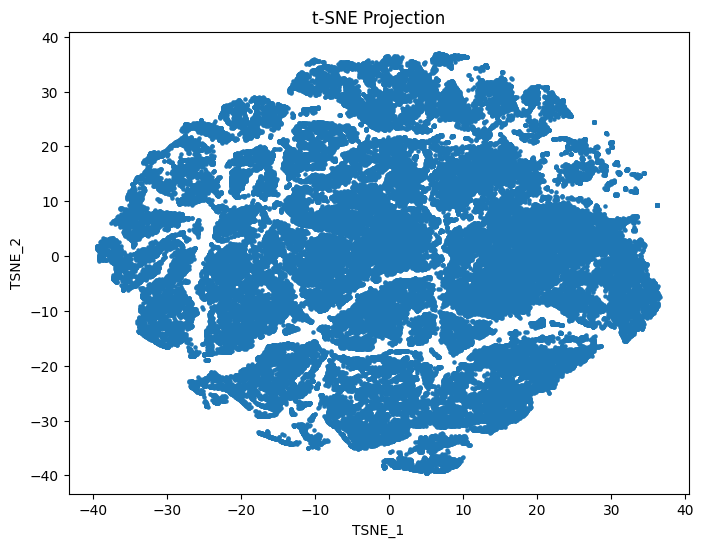

In [ ]:
 tsne_df = run_tsne(X_train_rating_scaled, perplexity=40, learning_rate=100)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_tsne(tsne_df, labels=None, title="t-SNE Projection", figsize=(8, 6), cmap="tab10"):
    """
    Plotta il risultato di un t-SNE.

    Parametri:
    ----------
    tsne_df : pd.DataFrame
        DataFrame con due colonne (TSNE_1, TSNE_2).
    labels : array-like o pd.Series, opzionale
        Etichette per colorare i punti (es. classi o categorie).
    title : str
        Titolo del grafico.
    figsize : tuple
        Dimensioni della figura.
    cmap : str
        Colormap da usare per le classi.
    """
    if not isinstance(tsne_df, pd.DataFrame):
        raise ValueError("tsne_df deve essere un DataFrame con colonne TSNE_1 e TSNE_2.")

    plt.figure(figsize=figsize)

    if labels is not None:
        scatter = plt.scatter(
            tsne_df["TSNE_1"],
            tsne_df["TSNE_2"],
            c=labels,
            cmap=cmap,
            s=5,
            alpha=0.8
        )
        plt.legend(
            *scatter.legend_elements(),
            title="Classi",
            loc="best",
            fontsize="small"
        )
    else:
        plt.scatter(tsne_df["TSNE_1"], tsne_df["TSNE_2"], s=5, alpha=0.8)

    plt.title(title)
    plt.xlabel("TSNE_1")
    plt.ylabel("TSNE_2")
    plt.show()

# Esempio d'uso:
# tsne_df = run_tsne(X_train_rating_scaled, plot=False)


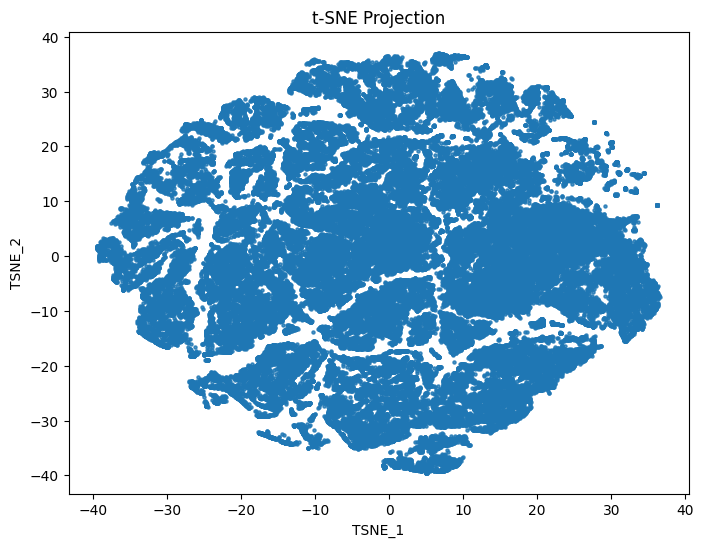

In [ ]:
plot_tsne(tsne_df)


#Estrazione DF Rating

In [ ]:
def run_outlier_pipeline(X_train_numeric, X_train_full, y_train, X_test_full, y_test,
                         contamination=0.05, n_neighbors=20):
    """
    Esegue l'intera pipeline: outlier detection, pulizia e training.
    Ritorna i dataset di training senza outlier (All3 e 2of3).
    """
    # Check di integrità sugli indici
    assert X_train_numeric.index.equals(X_train_full.index), \
        "Gli indici di X_train_numeric e X_train_full devono corrispondere."

    # Step 1: Outlier detection
    outlier_df = detect_outliers(X_train_numeric, contamination=contamination, n_neighbors=n_neighbors)

    # Step 2: Pulizia del dataset completo
    (X_all3, y_all3), (X_2of3, y_2of3) = generate_clean_datasets(X_train_full, y_train, outlier_df)

    # Step 3: Addestramento e valutazione
    #train_and_evaluate(X_all3, y_all3, X_test_full, y_test, label="No Outliers (All 3)")
    train_and_evaluate(X_2of3, y_2of3, X_test_full, y_test, label="No Outliers (2 of 3)")

    # ⬅️ Qui ritorni i dataset puliti
    return  (X_2of3, y_2of3)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.abod import ABOD
from sklearn.metrics import classification_report

def detect_outliers(X_numeric, contamination=0.05, n_neighbors=20, random_state=42):
    """
    Esegue la rilevazione outlier su un subset numerico.
    Ritorna un DataFrame booleano con le predizioni per ciascun algoritmo e somma.
    """
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    abod = ABOD(n_neighbors=n_neighbors, contamination=contamination)

    y_pred_lof = lof.fit_predict(X_numeric)
    y_pred_iso = iso.fit_predict(X_numeric)
    abod.fit(X_numeric)
    y_pred_abod = abod.labels_

    outlier_df = pd.DataFrame({
        'lof': y_pred_lof == -1,
        'iso': y_pred_iso == -1,
        'abod': y_pred_abod == 1
    }, index=X_numeric.index)

    outlier_df['sum'] = outlier_df.sum(axis=1)

    return outlier_df


def generate_clean_datasets(X_full, y, outlier_df):
    """
    Usa le predizioni degli outlier per pulire il dataset completo (X_full).
    Ritorna due versioni pulite: senza outlier comuni a 3/3 e 2/3 algoritmi.
    """
    mask_all3 = outlier_df['sum'] == 3
    mask_2plus = outlier_df['sum'] >= 2

    print(f"🧹 Outlier comuni a tutti e 3: {mask_all3.sum()}")
    print(f"🧹 Outlier comuni ad almeno 2 su 3: {mask_2plus.sum()}")

    if isinstance(y, np.ndarray):
        y = pd.Series(y, index=X_full.index)

    X_clean_all3 = X_full.loc[~mask_all3].copy().reset_index(drop=True)
    y_clean_all3 = y.loc[~mask_all3].copy().reset_index(drop=True)

    X_clean_2of3 = X_full.loc[~mask_2plus].copy().reset_index(drop=True)
    y_clean_2of3 = y.loc[~mask_2plus].copy().reset_index(drop=True)

    return (X_clean_all3, y_clean_all3), (X_clean_2of3, y_clean_2of3)


def train_and_evaluate(X_train, y_train, X_test, y_test, label=""):
    """
    Allena un RandomForestClassifier e stampa il classification report.
    """
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n📊 Risultati per dataset '{label}':")
    print(classification_report(y_test, y_pred, zero_division=0))

def run_outlier_pipeline(X_train_numeric, X_train_full, y_train, X_test_full, y_test,
                         contamination=0.05, n_neighbors=20):
    """
    Esegue la pipeline di outlier detection, pulizia e training.
    Ritorna solo i dataset di training senza outlier (2 of 3).
    """
    assert X_train_numeric.index.equals(X_train_full.index), \
        "Gli indici di X_train_numeric e X_train_full devono corrispondere."

    outlier_df = detect_outliers(X_train_numeric, contamination=contamination, n_neighbors=n_neighbors)
    (_, _), (X_2of3, y_2of3) = generate_clean_datasets(X_train_full, y_train, outlier_df)

    train_and_evaluate(X_2of3, y_2of3, X_test_full, y_test, label="No Outliers (2 of 3)")

    return X_2of3, y_2of3


In [ ]:
from google.colab import files

In [ ]:
# Esecuzione e salvataggio
neighbors_list = [50]
for n in neighbors_list:
    print(f"\n🔍 Esecuzione pipeline con n_neighbors = {n}")
    X_2of3, y_2of3 = run_outlier_pipeline(
        X_train_numeric=X_train_rating_scaled,
        X_train_full=X_train_rating_final,
        y_train=y_train_rating,
        X_test_full=X_test_rating_final,
        y_test=y_test_rating,
        contamination=0.01,
        n_neighbors=n
    )



🔍 Esecuzione pipeline con n_neighbors = 50
🧹 Outlier comuni a tutti e 3: 58
🧹 Outlier comuni ad almeno 2 su 3: 751

📊 Risultati per dataset 'No Outliers (2 of 3)':
              precision    recall  f1-score   support

           1       0.52      0.17      0.26        64
           2       0.43      0.10      0.16       192
           3       0.39      0.08      0.13       516
           4       0.35      0.13      0.19      1512
           5       0.38      0.24      0.29      3769
           6       0.42      0.44      0.43      8246
           7       0.45      0.56      0.50     13559
           8       0.51      0.58      0.54     11998
           9       0.49      0.22      0.31      3583
          10       0.64      0.21      0.32       461

    accuracy                           0.46     43900
   macro avg       0.46      0.27      0.31     43900
weighted avg       0.46      0.46      0.45     43900



In [ ]:
X_test_rating_final.head()

,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,externalLinks,writerCredits,directorsCredits,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,1.043423,-0.778850,0.284623,-0.158866,-0.164070,-0.576993,-0.295002,-0.212881,1.593321,0.062745,...,0,0,0,0,1,0,0,0,0,0
1,-0.365379,-0.878494,-0.457998,-0.158866,-0.537147,-0.576993,-0.245227,-0.262389,-0.011492,0.062745,...,0,0,1,0,0,0,0,0,0,0
2,-1.548245,0.152962,1.077828,-0.158866,-0.537147,-0.576993,-0.295002,-0.262389,4.000540,0.062745,...,0,0,1,0,0,0,0,0,0,0
3,0.752262,0.599166,-1.005476,-0.158866,-0.350608,-0.576993,-0.245227,-0.262389,-0.813898,0.062745,...,0,0,0,0,0,0,0,0,1,0
4,-1.189699,-1.148094,0.399243,-0.158866,-0.350608,-0.576993,-0.295002,-0.262389,-0.412695,0.062745,...,0,1,0,0,0,0,0,0,0,0


In [ ]:

# Salvataggio su Colab
X_2of3.to_csv("X_2of3.csv", index=False)
y_2of3.to_csv("y_2of3.csv", index=False)

# Download immediato
files.download("X_2of3.csv")
files.download("y_2of3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.abod import ABOD
from sklearn.metrics import classification_report

def detect_outliers(X_numeric, contamination=0.05, n_neighbors=20, random_state=42):
    """
    Esegue la rilevazione outlier su un subset numerico.
    Ritorna un DataFrame booleano con le predizioni per ciascun algoritmo e somma.
    """
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    abod = ABOD(n_neighbors=n_neighbors, contamination=contamination)

    y_pred_lof = lof.fit_predict(X_numeric)
    y_pred_iso = iso.fit_predict(X_numeric)
    abod.fit(X_numeric)
    y_pred_abod = abod.labels_

    outlier_df = pd.DataFrame({
        'lof': y_pred_lof == -1,
        'iso': y_pred_iso == -1,
        'abod': y_pred_abod == 1
    }, index=X_numeric.index)

    outlier_df['sum'] = outlier_df.sum(axis=1)

    return outlier_df


def generate_clean_datasets(X_full, y, outlier_df):
    """
    Usa le predizioni degli outlier per pulire il dataset completo (X_full).
    Ritorna due versioni pulite: senza outlier comuni a 3/3 e 2/3 algoritmi.
    """
    mask_all3 = outlier_df['sum'] == 3
    mask_2plus = outlier_df['sum'] >= 2

    print(f"🧹 Outlier comuni a tutti e 3: {mask_all3.sum()}")
    print(f"🧹 Outlier comuni ad almeno 2 su 3: {mask_2plus.sum()}")

    if isinstance(y, np.ndarray):
        y = pd.Series(y, index=X_full.index)

    X_clean_all3 = X_full.loc[~mask_all3].copy().reset_index(drop=True)
    y_clean_all3 = y.loc[~mask_all3].copy().reset_index(drop=True)

    X_clean_2of3 = X_full.loc[~mask_2plus].copy().reset_index(drop=True)
    y_clean_2of3 = y.loc[~mask_2plus].copy().reset_index(drop=True)

    return (X_clean_all3, y_clean_all3), (X_clean_2of3, y_clean_2of3)


def train_and_evaluate(X_train, y_train, X_test, y_test, label=""):
    """
    Allena un RandomForestClassifier e stampa il classification report.
    """
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n📊 Risultati per dataset '{label}':")
    print(classification_report(y_test, y_pred, zero_division=0))

def run_outlier_pipeline(X_train_numeric, X_train_full, y_train, X_test_full, y_test,
                         contamination=0.05, n_neighbors=20):

    assert X_train_numeric.index.equals(X_train_full.index), \
        "Gli indici di X_train_numeric e X_train_full devono corrispondere."

    # Step 1: outlier detection
    outlier_df = detect_outliers(X_train_numeric, contamination=contamination, n_neighbors=n_neighbors)

    # Step 2: pulizia dataset
    (_, _), (X_2of3, y_2of3) = generate_clean_datasets(X_train_full, y_train, outlier_df)

    # Step 3: training
    train_and_evaluate(X_2of3, y_2of3, X_test_full, y_test, label="No Outliers (2 of 3)")

    # Recupero indici outlier (almeno 2 su 3 algoritmi)
    outlier_idx_2of3 = outlier_df[outlier_df['sum'] >= 2].index

    return X_2of3, y_2of3, outlier_idx_2of3


In [ ]:
X_2of3, y_2of3, outlier_idx = run_outlier_pipeline(
    X_train_numeric=X_train_rating_scaled,
    X_train_full=X_train_rating_final,
    y_train=y_train_rating,
    X_test_full=X_test_rating_final,
    y_test=y_test_rating,
    contamination=0.01,
    n_neighbors=50
)

print("Indici outlier:", outlier_idx.tolist())


🧹 Outlier comuni a tutti e 3: 58
🧹 Outlier comuni ad almeno 2 su 3: 751

📊 Risultati per dataset 'No Outliers (2 of 3)':
              precision    recall  f1-score   support

           1       0.52      0.17      0.26        64
           2       0.43      0.10      0.16       192
           3       0.39      0.08      0.13       516
           4       0.35      0.13      0.19      1512
           5       0.38      0.24      0.29      3769
           6       0.42      0.44      0.43      8246
           7       0.45      0.56      0.50     13559
           8       0.51      0.58      0.54     11998
           9       0.49      0.22      0.31      3583
          10       0.64      0.21      0.32       461

    accuracy                           0.46     43900
   macro avg       0.46      0.27      0.31     43900
weighted avg       0.46      0.46      0.45     43900

Indici outlier: [97, 310, 462, 646, 865, 936, 1315, 1324, 1402, 1618, 1683, 1726, 2008, 2145, 2237, 2262, 2321, 2465, 35

In [ ]:
# Salvataggio indici in CSV
outlier_idx.to_series().to_csv("outlier_indices_rating.csv", index=False)

# Download se sei su Colab
from google.colab import files
files.download("outlier_indices_rating.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Recupero solo le etichette degli outlier
y_outliers = y_train_rating.loc[outlier_idx]

# Grafico distribuzione con percentuali
#plot_outlier_distribution(y_outliers)


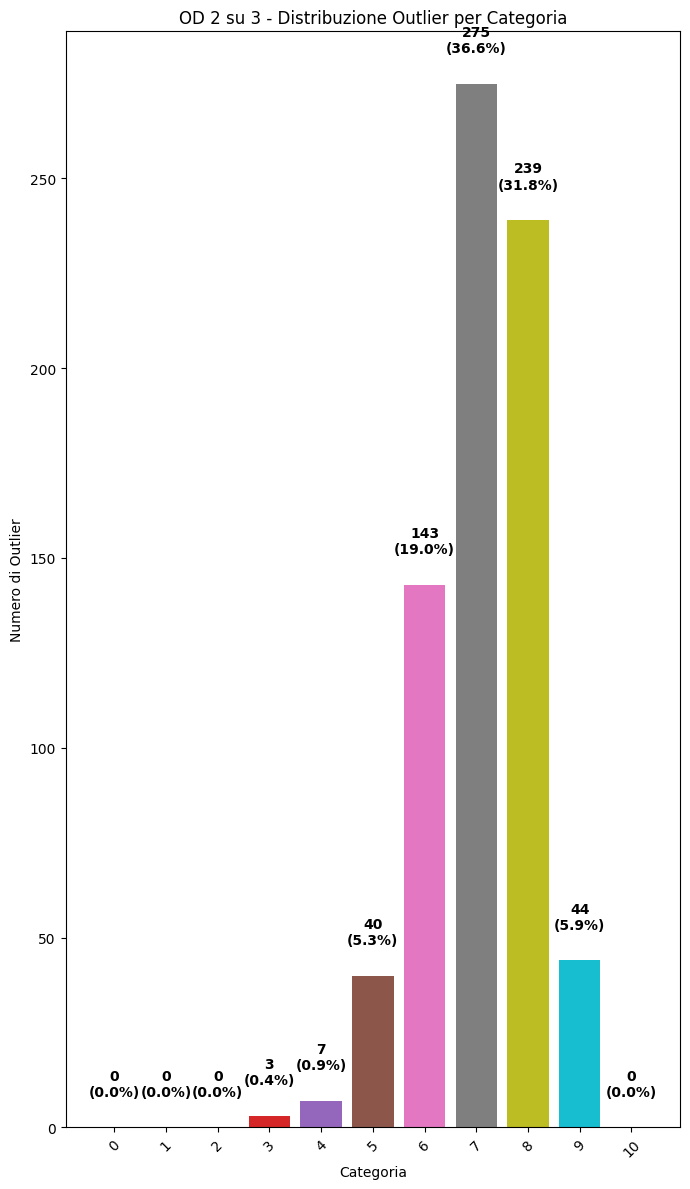

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mapping numerico → categoria
label_map = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
    5: '5',
    6: '6',
    7: '7',
    8: '8',
    9: '9',
    10: '10'
}

# --- Conversione in Series monodimensionale ---
if isinstance(y_outliers, pd.DataFrame):
    y_outliers_series = y_outliers.iloc[:, 0]  # prende la prima colonna
elif hasattr(y_outliers, "shape") and len(y_outliers.shape) > 1 and y_outliers.shape[1] == 1:
    y_outliers_series = pd.Series(y_outliers.ravel())
else:
    y_outliers_series = pd.Series(y_outliers)

# --- Mappatura codici → nomi ---
y_outliers_named = y_outliers_series.map(label_map)

# Ordine categorie secondo la legenda
category_order = [label_map[i] for i in range(len(label_map))]

# Conteggio per categoria, mantenendo l'ordine
counts = y_outliers_named.value_counts().reindex(category_order, fill_value=0)
total = counts.sum()

# Colori diversi per categoria
palette = sns.color_palette("tab10", len(counts))

# --- Plot ---
plt.figure(figsize=(7,12))
bars = plt.bar(counts.index, counts.values, color=palette)

# Etichette su ogni barra con numero + percentuale
for bar, count in zip(bars, counts.values):
    perc = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             count + total*0.01,
             f"{count}\n({perc:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titoli e assi
plt.title("OD 2 su 3 - Distribuzione Outlier per Categoria")
plt.xlabel("Categoria")
plt.ylabel("Numero di Outlier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Estrazione DF TitleType

In [ ]:
from google.colab import files

In [ ]:

# Salvataggio su Colab
X_test_title_final.to_csv("X_test_title_final.csv", index=False)
y_test_title.to_csv("y_test_title.csv", index=False)

# Download immediato
files.download("X_test_title_final.csv")
files.download("y_test_title.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_test_rating.shape

NameError: name 'y_test_rating' is not defined

In [ ]:
X_test_title_final.shape

(43900, 50)

In [ ]:
# Salva gli indici del dataset originale
original_indices = X_train_title_final.index

# Trova gli indici degli outlier (quelli che non sono nel dataset pulito)
outlier_indices = original_indices.difference(clean_indices)

print(f"Indici degli outlier: {outlier_indices}")

NameError: name 'X_title_2of3' is not defined

In [ ]:

# Salvataggio su Colab
X_2of3.to_csv("X_title_2of3.csv", index=False)
y_2of3.to_csv("y_title_2of3.csv", index=False)

# Download immediato
files.download("X_title_2of3.csv")
files.download("y_title_2of3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#recupero outlier con idx

In [ ]:
# Salvataggio indici in CSV
outlier_idx.to_series().to_csv("outlier_indices.csv", index=False)

# Download se sei su Colab
from google.colab import files
files.download("outlier_indices.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

def plot_outlier_distribution(y_outliers):
    counts = y_outliers.value_counts()
    total = counts.sum()

    ax = counts.plot(kind="bar", figsize=(8, 5))
    plt.title("Distribuzione classi tra gli outlier (2 of 3)")
    plt.xlabel("Classe")
    plt.ylabel("Frequenza")

    # Aggiunta etichette con valori e percentuali
    for i, (val, count) in enumerate(counts.items()):
        perc = (count / total) * 100
        ax.text(i, count + 0.5, f"{count} ({perc:.1f}%)",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.xticks(rotation=45)
    plt.ylim(0, counts.max() * 1.15)
    plt.show()


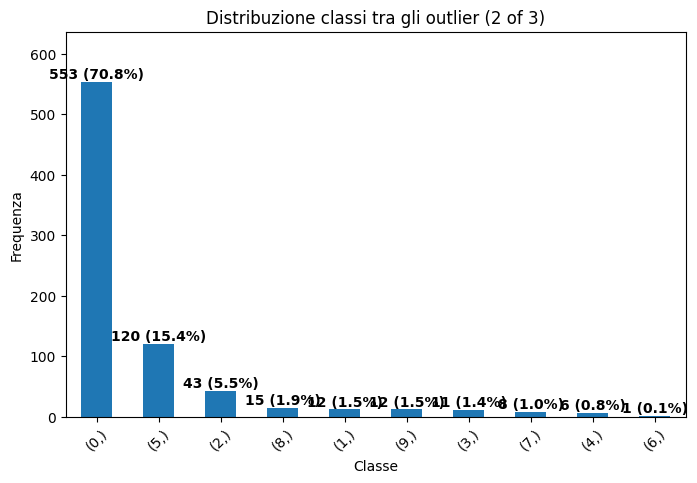

In [ ]:
# Recupero solo le etichette degli outlier
y_outliers = y_train_title.loc[outlier_idx]

# Grafico distribuzione con percentuali
plot_outlier_distribution(y_outliers)


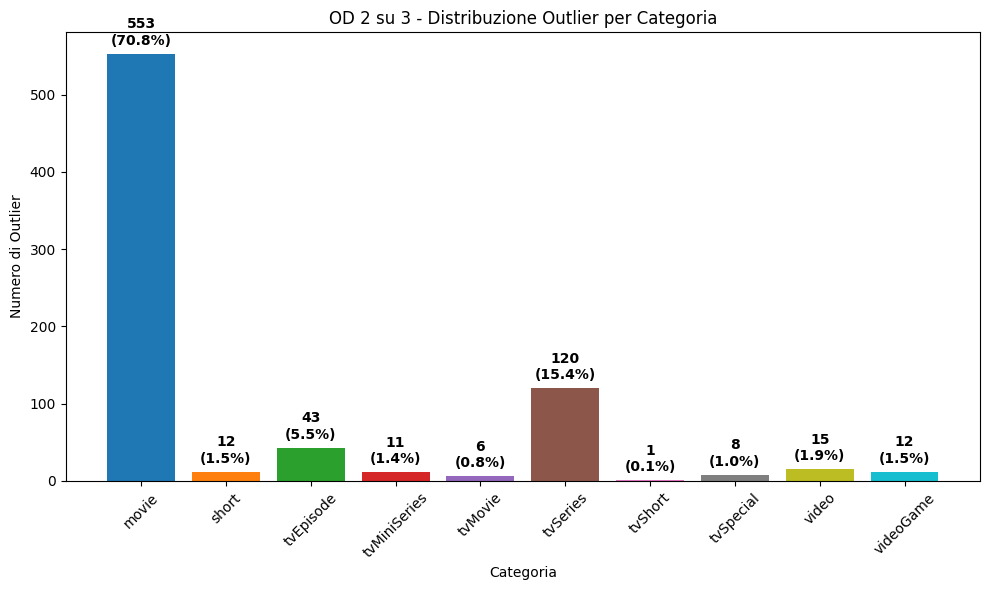

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mapping numerico → categoria
label_map = {
    0: 'movie',
    1: 'short',
    2: 'tvEpisode',
    3: 'tvMiniSeries',
    4: 'tvMovie',
    5: 'tvSeries',
    6: 'tvShort',
    7: 'tvSpecial',
    8: 'video',
    9: 'videoGame'
}

# --- Conversione in Series monodimensionale ---
if isinstance(y_outliers, pd.DataFrame):
    y_outliers_series = y_outliers.iloc[:, 0]  # prende la prima colonna
elif hasattr(y_outliers, "shape") and len(y_outliers.shape) > 1 and y_outliers.shape[1] == 1:
    y_outliers_series = pd.Series(y_outliers.ravel())
else:
    y_outliers_series = pd.Series(y_outliers)

# --- Mappatura codici → nomi ---
y_outliers_named = y_outliers_series.map(label_map)

# Ordine categorie secondo la legenda
category_order = [label_map[i] for i in range(len(label_map))]

# Conteggio per categoria, mantenendo l'ordine
counts = y_outliers_named.value_counts().reindex(category_order, fill_value=0)
total = counts.sum()

# Colori diversi per categoria
palette = sns.color_palette("tab10", len(counts))

# --- Plot ---
plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color=palette)

# Etichette su ogni barra con numero + percentuale
for bar, count in zip(bars, counts.values):
    perc = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             count + total*0.01,
             f"{count}\n({perc:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titoli e assi
plt.title("OD 2 su 3 - Distribuzione Outlier per Categoria")
plt.xlabel("Categoria")
plt.ylabel("Numero di Outlier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


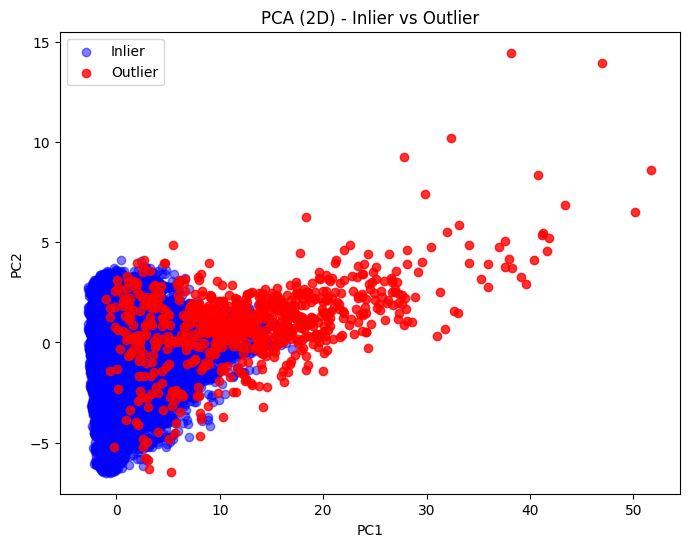

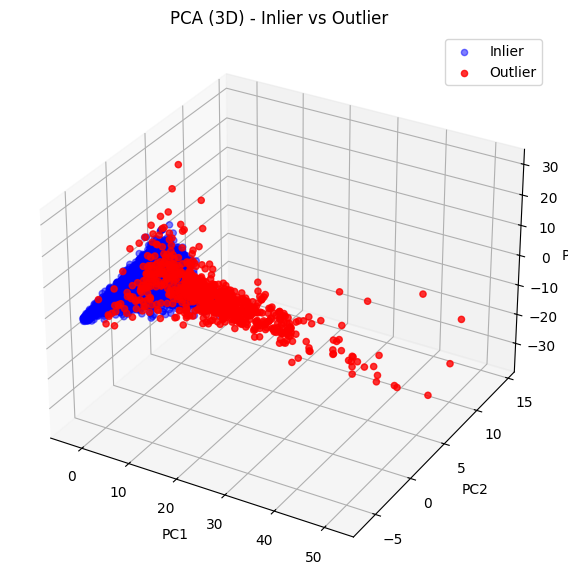

In [ ]:
plot_pca_2d(X_train_title_scaled, outlier_idx)
plot_pca_3d(X_train_title_scaled, outlier_idx)

In [ ]:
# ====== Mappa etichette ======
label_map = {
    0: 'movie',
    1: 'short',
    2: 'tvEpisode',
    3: 'tvMiniSeries',
    4: 'tvMovie',
    5: 'tvSeries',
    6: 'tvShort',
    7: 'tvSpecial',
    8: 'video',
    9: 'videoGame'
}

# ====== Funzioni PCA ======
def plot_pca_2d_colored(X_numeric, outlier_idx, y_outliers_named):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_numeric)

    mask_outliers = X_numeric.index.isin(outlier_idx)
    mask_inliers = ~mask_outliers

    plt.figure(figsize=(10, 7))

    # Inlier in blu
    plt.scatter(X_pca[mask_inliers, 0], X_pca[mask_inliers, 1],
                c='blue', label='Inlier', alpha=0.4)

    # Outlier per categoria
    categories = sorted(y_outliers_named.dropna().unique())
    palette = sns.color_palette("tab10", len(categories))

    for cat, color in zip(categories, palette):
        mask_cat = mask_outliers & (y_outliers_named == cat)
        plt.scatter(X_pca[mask_cat, 0], X_pca[mask_cat, 1],
                    color=color, label=f"Outlier - {cat}", alpha=0.8)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA (2D) - Inlier vs Outlier per Categoria")
    plt.legend()
    plt.show()


def plot_pca_3d_colored(X_numeric, outlier_idx, y_outliers_named):
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_numeric)

    mask_outliers = X_numeric.index.isin(outlier_idx)
    mask_inliers = ~mask_outliers

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Inlier in blu
    ax.scatter(X_pca[mask_inliers, 0], X_pca[mask_inliers, 1], X_pca[mask_inliers, 2],
               c='blue', label='Inlier', alpha=0.4)

    # Outlier per categoria
    categories = sorted(y_outliers_named.dropna().unique())
    palette = sns.color_palette("tab10", len(categories))

    for cat, color in zip(categories, palette):
        mask_cat = mask_outliers & (y_outliers_named == cat)
        ax.scatter(X_pca[mask_cat, 0], X_pca[mask_cat, 1], X_pca[mask_cat, 2],
                   color=color, label=f"Outlier - {cat}", alpha=0.8)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("PCA (3D) - Inlier vs Outlier per Categoria")
    ax.legend()
    plt.show()


In [ ]:
# Crea Serie con label per tutti i punti
y_outliers_named_full = pd.Series('inlier', index=X_train_title_scaled.index)

# Sovrascrivi solo gli outlier con la loro categoria (mappata)
y_outliers_named_full.loc[outlier_idx] = y_train_title.loc[outlier_idx].map(label_map)

# Ora puoi usare le funzioni di plot PCA senza cambiare nulla
plot_pca_2d_colored(X_train_title_scaled, outlier_idx, y_outliers_named_full)
plot_pca_3d_colored(X_train_title_scaled, outlier_idx, y_outliers_named_full)


TypeError: the first argument must be callable